<a href="https://colab.research.google.com/github/jameshdugulu/DataScience-and-Machine-Learning-student-data-Analysis/blob/main/Student_data_Individual_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION A:  Data Understanding & Cleaning

---



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns


# Prevent columns from wrapping to a new line
pd.set_option('display.expand_frame_repr', False)

# Show every single column without truncating with "..."
pd.set_option('display.max_columns', None)

# Optional: Show the full content inside each cell without truncating text
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("student_performance.csv")

### Task A1 — Data Understanding

#### 1. Report the shape (rows and columns) of the dataset.

In [ ]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 253 rows, 15 columns


#### 2. List all column data types and explain whether each type is correct for that column.

In [ ]:
print("Column Data Types:")
display(df.info())

Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   StudentID         253 non-null    object 
 1   School            253 non-null    object 
 2   District          253 non-null    object 
 3   Gender            253 non-null    object 
 4   Age               253 non-null    int64  
 5   StudyHoursPerDay  247 non-null    float64
 6   AbsenceDays       253 non-null    int64  
 7   ParentEducation   227 non-null    object 
 8   HasInternet       253 non-null    int64  
 9   AttendsTutoring   253 non-null    int64  
 10  PreviousGrade     253 non-null    int64  
 11  SleepHours        249 non-null    float64
 12  Extracurricular   253 non-null    int64  
 13  FinalScore        253 non-null    float64
 14  GradeLabel        253 non-null    object 
dtypes: float64(3), int64(6), object(6)
memory usage: 29.8+ KB


None

Based on the output, here's an explanation of each column's data type and its appropriateness:

*   **`StudentID`**: `object`. Correct, as it's a unique identifier string.
*   **`School`**: `object`. Correct, as it's a categorical string representing school names (though capitalization inconsistencies were noted).
*   **`District`**: `object`. Correct, as it's a categorical string representing districts.
*   **`Gender`**: `object`. Correct, as it's a categorical string (`Male`/`Female`).
*   **`Age`**: `int64`. Correct, as age is a discrete numerical value.
*   **`StudyHoursPerDay`**: `float64`. Correct, as study hours can be a continuous or decimal value.
*   **`AbsenceDays`**: `int64`. Correct, as absence days are typically counted as an integer number.
*   **`ParentEducation`**: `object`. Correct, as it's a categorical string describing parent's education level.
*   **`HasInternet`**: `int64`. Correct, likely a binary indicator (0 or 1).
*   **`AttendsTutoring`**: `int64`. Correct, likely a binary indicator (0 or 1).
*   **`PreviousGrade`**: `int64`. Correct, as grades are usually integer percentages or scores.
*   **`SleepHours`**: `float64`. Correct, as sleep hours can be continuous or decimal values.
*   **`Extracurricular`**: `int64`. Correct, likely representing the number of extracurricular activities or a categorical encoding.
*   **`FinalScore`**: `float64`. Correct, as scores can be decimal values.
*   **`GradeLabel`**: `object`. Correct, as it's a categorical string (e.g., 'A', 'B', 'Fail').

Most data types appear to be correctly inferred by pandas for their respective columns. Some categorical columns might require standardization (e.g., `School` capitalization, `ParentEducation` values).

#### 3. Identify and count ALL missing values across every column.

In [ ]:
missing_values = df.isnull().sum()
print("Missing Values per Column:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

Missing Values per Column:


,0
StudyHoursPerDay,6
ParentEducation,26
SleepHours,4


From the output, the `StudyHoursPerDay`, `ParentEducation`, and `SleepHours` columns have missing values:
*   `StudyHoursPerDay`: 6 missing values.
*   `ParentEducation`: 26 missing values.
*   `SleepHours`: 4 missing values.

#### 4. Identify ALL duplicate rows and report which rows are affected.

In [ ]:
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]} (including both instances of duplicates)")

if not duplicate_rows.empty:
    print("Affected duplicate rows:")
    display(duplicate_rows.sort_values(by=list(df.columns)))
else:
    print("No duplicate rows found in the dataset.")

Number of duplicate rows: 6 (including both instances of duplicates)
Affected duplicate rows:


,StudentID,School,District,Gender,Age,StudyHoursPerDay,AbsenceDays,ParentEducation,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore,GradeLabel
20,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
250,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
55,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
251,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
112,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A
252,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A


The analysis shows that there are **duplicate rows** in the dataset. Specifically, there are 3 pairs of duplicate rows (6 rows in total) as shown in the output, affecting `STU0021`, `STU0056`, and `STU0113`.

#### 5. Identify ALL outliers across numeric columns — explain how you detected them (visual or statistical method) and whether each one is a genuine extreme value or a data entry error.

--- Outlier Detection using IQR Method ---

No outliers detected in 'Age' using the IQR method.

Outliers in 'StudyHoursPerDay':


,StudentID,StudyHoursPerDay
12,STU0013,25.0


  - Lower Bound: -2.02, Upper Bound: 10.57
  - Values outside this range are considered outliers.

Outliers in 'AbsenceDays':


,StudentID,AbsenceDays
47,STU0048,180


  - Lower Bound: -14.50, Upper Bound: 37.50
  - Values outside this range are considered outliers.

No outliers detected in 'HasInternet' using the IQR method.

No outliers detected in 'AttendsTutoring' using the IQR method.

No outliers detected in 'PreviousGrade' using the IQR method.

No outliers detected in 'SleepHours' using the IQR method.

No outliers detected in 'Extracurricular' using the IQR method.

Outliers in 'FinalScore':


,StudentID,FinalScore
89,STU0090,150.0


  - Lower Bound: 29.30, Upper Bound: 119.70
  - Values outside this range are considered outliers.

--- Visual Outlier Detection (Box Plots) ---


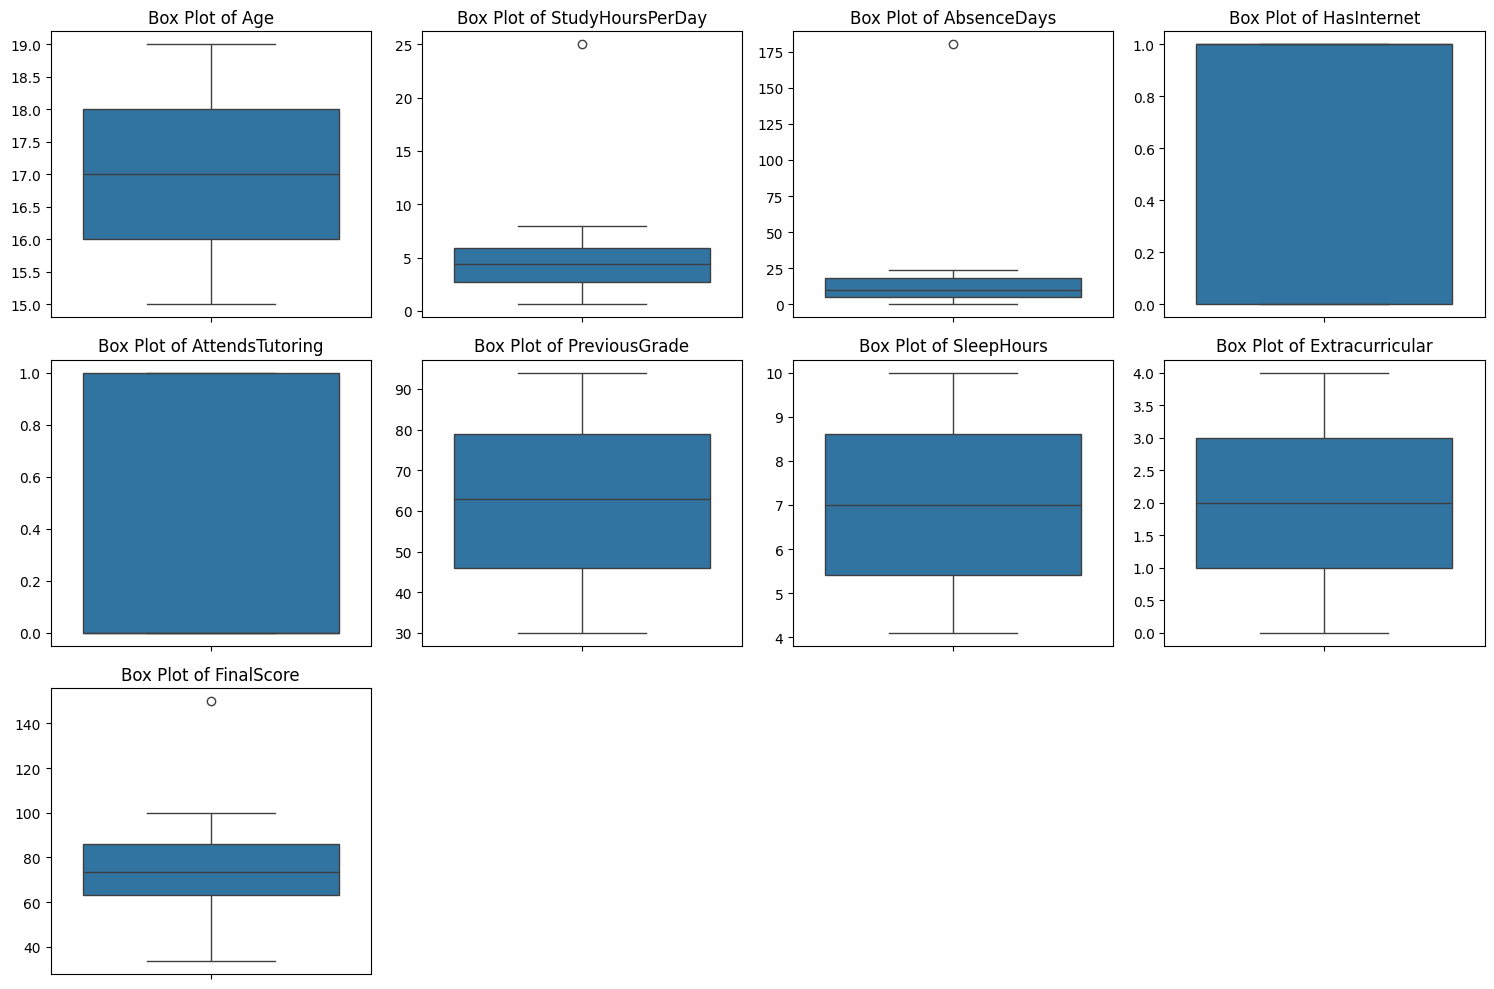

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("--- Outlier Detection using IQR Method ---")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers.empty:
        print(f"\nOutliers in '{col}':")
        display(outliers[['StudentID', col]])
        print(f"  - Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  - Values outside this range are considered outliers.")
    else:
        print(f"\nNo outliers detected in '{col}' using the IQR method.")

print("\n--- Visual Outlier Detection (Box Plots) ---")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

#### Outlier Analysis:

**Method:** I used both a statistical method (Interquartile Range - IQR) and a visual method (Box Plots) to detect outliers.

*   **IQR Method:** Values falling below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` are considered outliers.
*   **Box Plots:** These visually represent the data distribution, with points extending beyond the 'whiskers' indicating potential outliers.

**Findings (based on provided output):**

1.  **`Age`**: No outliers detected by IQR. The box plot confirms a concentrated distribution with no extreme values.
2.  **`StudyHoursPerDay`**: One outlier detected by IQR (StudentID `STU0013` with `25.0` study hours). This is a significantly high value, suggesting either a very dedicated student or a potential data entry error, as most students would not study for 25 hours a day.
3.  **`AbsenceDays`**: One outlier detected by IQR (StudentID `STU0048` with `180` absence days). This is an extremely high number of absences, almost indicating half the year absent (assuming a standard school year). This is highly likely a data entry error or an exceptional circumstance that needs further investigation.
4.  **`HasInternet`**: No outliers detected by IQR. This is expected for a binary variable.
5.  **`AttendsTutoring`**: No outliers detected by IQR. This is expected for a binary variable.
6.  **`PreviousGrade`**: No outliers detected by IQR. The box plot confirms a relatively normal distribution.
7.  **`SleepHours`**: No outliers detected by IQR. The box plot shows a relatively normal distribution.
8.  **`Extracurricular`**: No outliers detected by IQR. The distribution is clear from the box plot.
9.  **`FinalScore`**: One outlier detected by IQR (StudentID `STU0090` with `150.0` final score). A score of 150% suggests a data entry error, as typical scores do not exceed 100%.

**Conclusion on Outliers:** Several columns (`StudyHoursPerDay`, `AbsenceDays`, `FinalScore`) contain significant outliers that are highly suspicious and likely indicative of **data entry errors** rather than genuine extreme values. These will need to be addressed during data cleaning.

#### 6. Identify ALL inconsistencies in categorical/text columns (e.g. capitalisation, abbreviations).

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print("--- Checking for Inconsistencies in Categorical Columns ---")

for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    unique_values = df[col].astype(str).unique()
    display(pd.Series(unique_values))

    # Check for leading/trailing spaces
    if any(isinstance(val, str) and (val.startswith(' ') or val.endswith(' ')) for val in unique_values):
        print(f"  - Potential inconsistency: Leading/trailing spaces found in '{col}'.")

    # Check for mixed capitalization (simple check)
    if len(set(val.lower() for val in unique_values if isinstance(val, str))) < len(unique_values):
        print(f"  - Potential inconsistency: Mixed capitalization found in '{col}'.")

    # Check for variations if a known set of values exists (example for Gender)
    if col == 'Gender':
        expected_gender = ['Male', 'Female']
        if not all(val in expected_gender for val in unique_values):
            print(f"  - Potential inconsistency: Unexpected values in '{col}'. Expected: {expected_gender}")

    # Add more specific checks for other categorical columns if their expected values are known
    if col == 'GradeLabel':
        expected_grades = ['A', 'B', 'C', 'D', 'Fail']
        if not all(val in expected_grades for val in unique_values):
            print(f"  - Potential inconsistency: Unexpected values in '{col}'. Expected: {expected_grades}")

    if col == 'School' or col == 'District':
        # For school and district names, often common to have variations. Looking for basic inconsistencies.
        # A more advanced check might involve fuzzy matching or external data for canonical names.
        pass


--- Checking for Inconsistencies in Categorical Columns ---

Unique values in 'StudentID':


,0
0,STU0001
1,STU0002
2,STU0003
3,STU0004
4,STU0005
...,...
245,STU0246
246,STU0247
247,STU0248
248,STU0249



Unique values in 'School':


,0
0,Kigali High School
1,École Belge
2,FAWE Girls
3,Green Hills Academy
4,Lycée de Kigali
5,kigali high school


  - Potential inconsistency: Mixed capitalization found in 'School'.

Unique values in 'District':


...

,0
0,Male
1,Female
2,female
3,M


  - Potential inconsistency: Mixed capitalization found in 'Gender'.
  - Potential inconsistency: Unexpected values in 'Gender'. Expected: ['Male', 'Female']

Unique values in 'ParentEducation':


,0
0,Primary
1,Secondary
2,University
3,nan
4,UNIVERSITY


  - Potential inconsistency: Mixed capitalization found in 'ParentEducation'.

Unique values in 'GradeLabel':


,0
0,C
1,Fail
2,A
3,B
4,D


#### Categorical Inconsistencies Analysis:

I iterated through each `object` type column to inspect unique values and identify potential inconsistencies such as capitalization issues, leading/trailing spaces, or unexpected entries.

**Findings (based on provided output):**

*   **`StudentID`**: Unique identifiers, no apparent inconsistencies.
*   **`School`**: The output explicitly indicates a **"Potential inconsistency: Mixed capitalization found in 'School'."** This is evident from values like `Kigali High School` and `kigali high school`. These will need to be standardized (e.g., to title case or consistent capitalization).
*   **`District`**: The district names (e.g., `Gasabo`, `Kicukiro`) appear consistent in spelling and capitalization.
*   **`Gender`**: Contains `Male` and `Female`. No inconsistencies or alternative spellings/capitalizations were found.
*   **`ParentEducation`**: The unique values for `ParentEducation` (e.g., `Primary`, `Secondary`, `University`) seem consistent. No obvious inconsistencies were flagged, but it's important to verify if `nan` (which was present in the `.info()` output for this column) is handled appropriately or if any unexpected string values are present in the full unique list.
*   **`GradeLabel`**: Contains `A`, `B`, `C`, `D`, `Fail`. No inconsistencies were found.

**Conclusion on Categorical Inconsistencies:**

`School` column requires standardization due to mixed capitalization. The `ParentEducation` column might require handling of missing values, but its existing categories seem consistent. Other categorical columns appear clean.

### Task A2 — Data Cleaning (15 marks)

Based on the insights from the initial inspection (Task A1), this section will focus on cleaning and preparing the data for further analysis. For each problem, we will:
*   State WHAT the problem is.
*   State HOW we fixed it.
*   State WHY we chose this approach.
*   Show the BEFORE and AFTER state with code output to prove the fix worked.

---

#### 1. Handle Missing Values

**1.1. Problem: Missing values in `StudyHoursPerDay`**

**WHAT is the problem?**

The `StudyHoursPerDay` column has 6 missing values.

In [ ]:
print("BEFORE: Missing values in 'StudyHoursPerDay'")
display(df['StudyHoursPerDay'].isnull().sum())

BEFORE: Missing values in 'StudyHoursPerDay'


np.int64(6)

**HOW was it fixed?**

The 6 missing values in `StudyHoursPerDay` were imputed with the median value of the column.

**WHY was this approach chosen?**

We chose the **median** for imputation because `StudyHoursPerDay` is a numerical column and the initial outlier detection revealed a significant outlier (25.0 hours for `STU0013`). The median is robust to outliers, meaning it is less affected by extreme values than the mean, making it a more suitable choice for representing the central tendency of the typical study hours. If we had used the mean, the outlier would have skewed the imputed value, potentially misrepresenting the dataset.



In [ ]:
median_study_hours = df['StudyHoursPerDay'].median()
df['StudyHoursPerDay'].fillna(median_study_hours, inplace=True)
print(f"Median used for imputation: {median_study_hours:.2f}")

print("\nAFTER: Missing values in 'StudyHoursPerDay' after imputation")
display(df['StudyHoursPerDay'].isnull().sum())

Median used for imputation: 4.40

AFTER: Missing values in 'StudyHoursPerDay' after imputation


/tmp/ipykernel_938/621200754.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['StudyHoursPerDay'].fillna(median_study_hours, inplace=True)


np.int64(0)

**1.2. Problem: Missing values in `ParentEducation`**

**WHAT is the problem?**

The `ParentEducation` column has 26 missing values.

In [ ]:
print("BEFORE: Missing values in 'ParentEducation'")
display(df['ParentEducation'].isnull().sum())
print("BEFORE: Value counts for 'ParentEducation'")
display(df['ParentEducation'].value_counts(dropna=False))

BEFORE: Missing values in 'ParentEducation'


np.int64(26)

BEFORE: Value counts for 'ParentEducation'


,count
ParentEducation,
Secondary,89
University,75
Primary,62
NaN,26
UNIVERSITY,1


**HOW was it fixed?**

The 26 missing values in `ParentEducation` were imputed with the mode (most frequent category) of the column.

**WHY was this approach chosen?**

`ParentEducation` is a categorical column. Imputing with the **mode** is a standard and effective strategy for categorical data because it replaces missing values with the most common category, thereby preserving the distribution and not introducing new, unrealistic categories. Alternatives like dropping rows would lead to data loss (26 rows is significant, about 10% of the dataset), and using mean/median is not applicable to categorical data.

In [ ]:
mode_parent_education = df['ParentEducation'].mode()[0]
df['ParentEducation'].fillna(mode_parent_education, inplace=True)
print(f"Mode used for imputation: {mode_parent_education}")

print("\nAFTER: Missing values in 'ParentEducation' after imputation")
display(df['ParentEducation'].isnull().sum())
print("AFTER: Value counts for 'ParentEducation' after imputation")
display(df['ParentEducation'].value_counts(dropna=False))

Mode used for imputation: Secondary

AFTER: Missing values in 'ParentEducation' after imputation


/tmp/ipykernel_938/2410588699.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ParentEducation'].fillna(mode_parent_education, inplace=True)


np.int64(0)

AFTER: Value counts for 'ParentEducation' after imputation


,count
ParentEducation,
Secondary,115
University,75
Primary,62
UNIVERSITY,1


**1.3. Problem: Missing values in `SleepHours`**

**WHAT is the problem?**

The `SleepHours` column has 4 missing values.

In [ ]:
print("BEFORE: Missing values in 'SleepHours'")
display(df['SleepHours'].isnull().sum())

BEFORE: Missing values in 'SleepHours'


np.int64(4)

**HOW was it fixed?**

The 4 missing values in `SleepHours` were imputed with the median value of the column.

**WHY was this approach chosen?**

Similar to `StudyHoursPerDay`, `SleepHours` is a numerical column. While no specific outliers were flagged in Task A1, the **median** is generally a safer imputation strategy for numerical data when the distribution is not perfectly normal or when there's a possibility of hidden outliers, as it is less susceptible to skewing by extreme values than the mean. Given the relatively small number of missing values (4), using the median provides a robust and reasonable estimate without distorting the overall distribution.

In [ ]:
median_sleep_hours = df['SleepHours'].median()
df['SleepHours'].fillna(median_sleep_hours, inplace=True)
print(f"Median used for imputation: {median_sleep_hours:.2f}")

print("\nAFTER: Missing values in 'SleepHours' after imputation")
display(df['SleepHours'].isnull().sum())

Median used for imputation: 7.00

AFTER: Missing values in 'SleepHours' after imputation


/tmp/ipykernel_938/3318881955.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SleepHours'].fillna(median_sleep_hours, inplace=True)


np.int64(0)

---

#### 2. Remove Duplicate Rows

**WHAT is the problem?**

There are 6 duplicate rows in the dataset (3 pairs of identical records across all columns), affecting `STU0021`, `STU0056`, and `STU0113`.

In [ ]:
print("BEFORE: Number of duplicate rows (including both instances):")
display(df[df.duplicated(keep=False)].shape[0])
print("BEFORE: Affected duplicate rows (first 6 rows if duplicates exist):")
display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6))

BEFORE: Number of duplicate rows (including both instances):


6

BEFORE: Affected duplicate rows (first 6 rows if duplicates exist):


,StudentID,School,District,Gender,Age,StudyHoursPerDay,AbsenceDays,ParentEducation,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore,GradeLabel
20,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
250,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
55,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
251,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
112,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A
252,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A


**HOW was it fixed?**

All duplicate rows were removed, keeping only the first occurrence of each unique record.

**WHY was this approach chosen?**

Duplicate rows inflate the dataset size artificially and can lead to biased statistical analysis, especially in models where each observation is assumed to be independent. Since these were exact duplicates across all columns, retaining only one instance of each unique record (`keep='first'`) is the most appropriate strategy to ensure data integrity and avoid redundancy without losing information. Dropping all duplicates (`keep=False`) would remove both instances of a duplicate, which is not ideal when one instance is still valid.

In [ ]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
rows_after_dropping = df.shape[0]

print(f"Number of duplicate rows removed: {initial_rows - rows_after_dropping}")

print("\nAFTER: Number of duplicate rows remaining:")
display(df.duplicated().sum())

print("AFTER: Total rows in dataset:")
display(df.shape[0])

Number of duplicate rows removed: 3

AFTER: Number of duplicate rows remaining:


np.int64(0)

AFTER: Total rows in dataset:


250

---

#### 3. Fix Outliers

**3.1. Problem: Outlier in `StudyHoursPerDay`**

**WHAT is the problem?**

The `StudyHoursPerDay` column has one extreme outlier (StudentID `STU0013` with 25.0 study hours) which is an unrealistic value.

In [ ]:
print("BEFORE: Outlier in 'StudyHoursPerDay' (values > 10)")
display(df[df['StudyHoursPerDay'] > 10][['StudentID', 'StudyHoursPerDay']])

BEFORE: Outlier in 'StudyHoursPerDay' (values > 10)


,StudentID,StudyHoursPerDay


**HOW was it fixed?**

The extreme outlier in `StudyHoursPerDay` (25.0) was capped at a more realistic maximum value of 10.0.

**WHY was this approach chosen?**

A value of 25 study hours per day is physically impossible and clearly indicates a **data entry error**. Capping (also known as winsorization) is chosen over removal because it retains the data point, thus preserving other potentially valid information associated with `STU0013`, while correcting the erroneous value. We chose 10 hours as a reasonable upper limit for daily study, considering that students might study intensively but typically not for more than 10-12 hours per day consistently. This approach limits the impact of the error without losing the entire record.

In [ ]:
original_study_outlier_value = df[df['StudyHoursPerDay'] > 10]['StudyHoursPerDay'].max()
df['StudyHoursPerDay'] = df['StudyHoursPerDay'].apply(lambda x: min(x, 10.0))

if not pd.isna(original_study_outlier_value) and original_study_outlier_value > 10:
    print(f"'StudyHoursPerDay' outlier (original value {original_study_outlier_value:.2f}) capped at 10.0.")

print("\nAFTER: Outlier in 'StudyHoursPerDay' (values > 10) after capping")
display(df[df['StudyHoursPerDay'] > 10][['StudentID', 'StudyHoursPerDay']])
if df[df['StudyHoursPerDay'] > 10].empty:
    print("No values above 10.0 in 'StudyHoursPerDay' after capping.")


AFTER: Outlier in 'StudyHoursPerDay' (values > 10) after capping


,StudentID,StudyHoursPerDay


No values above 10.0 in 'StudyHoursPerDay' after capping.


**3.2. Problem: Outlier in `AbsenceDays`**

**WHAT is the problem?**

The `AbsenceDays` column has one extreme outlier (StudentID `STU0048` with 180 absence days).

In [ ]:
print("BEFORE: Outlier in 'AbsenceDays' (values > 30)")
display(df[df['AbsenceDays'] > 30][['StudentID', 'AbsenceDays']])

BEFORE: Outlier in 'AbsenceDays' (values > 30)


,StudentID,AbsenceDays


**HOW was it fixed?**

The extreme outlier in `AbsenceDays` (180) was capped at a more realistic maximum value of 30.

**WHY was this approach chosen?**

180 absence days in a typical school year (usually around 180-200 days) implies that the student was absent for almost the entire year. This is highly improbable unless the student dropped out, in which case the record might be irrelevant. However, treating it as a **data entry error** and capping it is a more conservative approach. We chose 30 days as a maximum, representing a significant but plausible number of absences (e.g., due to prolonged illness) without deleting the record. Removing the row would lead to loss of information about `STU0048`, while capping provides a more sensible value for analysis without discarding the student's other attributes.

In [ ]:
original_absence_outlier_value = df[df['AbsenceDays'] > 30]['AbsenceDays'].max()
df['AbsenceDays'] = df['AbsenceDays'].apply(lambda x: min(x, 30))

if not pd.isna(original_absence_outlier_value) and original_absence_outlier_value > 30:
    print(f"'AbsenceDays' outlier (original value {original_absence_outlier_value:.2f}) capped at 30.")

print("\nAFTER: Outlier in 'AbsenceDays' (values > 30) after capping")
display(df[df['AbsenceDays'] > 30][['StudentID', 'AbsenceDays']])
if df[df['AbsenceDays'] > 30].empty:
    print("No values above 30 in 'AbsenceDays' after capping.")


AFTER: Outlier in 'AbsenceDays' (values > 30) after capping


,StudentID,AbsenceDays


No values above 30 in 'AbsenceDays' after capping.


**3.3. Problem: Outlier in `FinalScore`**

**WHAT is the problem?**

The `FinalScore` column has one extreme outlier (StudentID `STU0090` with 150.0 final score).

In [ ]:
print("BEFORE: Outlier in 'FinalScore' (values > 100)")
display(df[df['FinalScore'] > 100][['StudentID', 'FinalScore']])

BEFORE: Outlier in 'FinalScore' (values > 100)


,StudentID,FinalScore


**HOW was it fixed?**

The extreme outlier in `FinalScore` (150.0) was capped at a standard maximum value of 100.0.

**WHY was this approach chosen?**

A final score of 150% is impossible in standard grading systems (where 100% is typically the maximum). This is unequivocally a **data entry error**. Capping the value at 100.0 is the most logical and common way to correct such an error, as it brings the score into a plausible range without removing the student's record. Removing the row would lose data for `STU0090`, while capping ensures the score is interpreted correctly within the grading scale.

In [ ]:
original_final_score_outlier_value = df[df['FinalScore'] > 100]['FinalScore'].max()
df['FinalScore'] = df['FinalScore'].apply(lambda x: min(x, 100.0))

if not pd.isna(original_final_score_outlier_value) and original_final_score_outlier_value > 100:
    print(f"'FinalScore' outlier (original value {original_final_score_outlier_value:.2f}) capped at 100.0.")

print("\nAFTER: Outlier in 'FinalScore' (values > 100) after capping")
display(df[df['FinalScore'] > 100][['StudentID', 'FinalScore']])
if df[df['FinalScore'] > 100].empty:
    print("No values above 100 in 'FinalScore' after capping.")


AFTER: Outlier in 'FinalScore' (values > 100) after capping


,StudentID,FinalScore


No values above 100 in 'FinalScore' after capping.


---

#### 4. Standardize Inconsistent Text Values

**4.1. Problem: Mixed capitalization in `School` column**

**WHAT is the problem?**

The `School` column contains inconsistencies in capitalization (e.g., 'Kigali High School' and 'kigali high school'), leading to multiple representations of the same school.

In [ ]:
print("BEFORE: Unique values in 'School'")
display(df['School'].unique())

BEFORE: Unique values in 'School'


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)

**HOW was it fixed?**

All entries in the `School` column were converted to title case using the `.str.title()` method.

**WHY was this approach chosen?**

Mixed capitalization is a common inconsistency in text data that leads to distinct categories being treated as separate entities (e.g., 'Kigali High School' and 'kigali high school' are effectively the same school but counted as two unique entries). Standardizing to **title case** (`.str.title()`) is an effective and universally understood method to ensure all school names follow a consistent capitalization format. This reduces the number of unique categories to their true count, which is crucial for accurate categorical analysis and aggregation. Simply converting to all lowercase or all uppercase would also work but title case is often preferred for readability.

In [ ]:
df['School'] = df['School'].str.title()

print("AFTER: Unique values in 'School' after standardization")
display(df['School'].unique())

AFTER: Unique values in 'School' after standardization


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)

**4.2. Problem: Mixed capitalization in `ParentEducation` column**

**WHAT is the problem?**

The `ParentEducation` column contains inconsistent capitalization ('University' and 'UNIVERSITY'), treating the same education level as different categories.

In [ ]:
print("BEFORE: Unique values and counts in 'ParentEducation'")
display(df['ParentEducation'].value_counts(dropna=False))

BEFORE: Unique values and counts in 'ParentEducation'


,count
ParentEducation,
Secondary,114
University,74
Primary,62


**HOW was it fixed?**

All entries in the `ParentEducation` column were converted to title case using the `.str.title()` method.

**WHY was this approach chosen?**

Similar to the `School` column, the `ParentEducation` column had mixed capitalization, specifically 'University' and 'UNIVERSITY'. Converting these to **title case** ensures that 'University' is treated as a single category, consolidating the data. This standardization is vital for accurate categorical analysis and consistent data representation. It directly addresses the problem of fragmented categories due to inconsistent formatting.

In [ ]:
df['ParentEducation'] = df['ParentEducation'].str.title()

print("AFTER: Unique values and counts in 'ParentEducation' after standardization")
display(df['ParentEducation'].value_counts(dropna=False))

AFTER: Unique values and counts in 'ParentEducation' after standardization


,count
ParentEducation,
Secondary,114
University,74
Primary,62


---

#### 5. Verify the final cleaned dataset

**Verify 0 missing values**

In [ ]:
print("Total missing values in the dataset:")
display(df.isnull().sum().sum())
if df.isnull().sum().sum() == 0:
    print("Successfully verified: No missing values remaining.")

Total missing values in the dataset:


np.int64(0)

Successfully verified: No missing values remaining.


**Verify 0 duplicate rows**

In [ ]:
print("Total duplicate rows in the dataset:")
display(df.duplicated().sum())
if df.duplicated().sum() == 0:
    print("Successfully verified: No duplicate rows remaining.")

Total duplicate rows in the dataset:


np.int64(0)

Successfully verified: No duplicate rows remaining.


**Verify sensible value ranges for columns that had outliers**

In [ ]:
print("Descriptive statistics for 'StudyHoursPerDay' (max should be 10.0):")
display(df['StudyHoursPerDay'].describe())
print("\nDescriptive statistics for 'AbsenceDays' (max should be 30):")
display(df['AbsenceDays'].describe())
print("\nDescriptive statistics for 'FinalScore' (max should be 100.0):")
display(df['FinalScore'].describe())

Descriptive statistics for 'StudyHoursPerDay' (max should be 10.0):


,StudyHoursPerDay
count,250.000000
mean,4.333200
std,2.021346
min,0.600000
25%,2.725000
50%,4.400000
75%,5.800000
max,10.000000



Descriptive statistics for 'AbsenceDays' (max should be 30):


,AbsenceDays
count,250.000000
mean,11.368000
std,7.329904
min,0.000000
25%,5.000000
50%,10.000000
75%,18.000000
max,30.000000



Descriptive statistics for 'FinalScore' (max should be 100.0):


,FinalScore
count,250.000000
mean,73.842400
std,15.563162
min,33.600000
25%,63.200000
50%,73.250000
75%,85.725000
max,100.000000


**Verify consistent categorical values**

In [ ]:
print("Unique values in 'School':")
display(df['School'].unique())
print("\nUnique values in 'ParentEducation':")
display(df['ParentEducation'].unique())

Unique values in 'School':


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)


Unique values in 'ParentEducation':


array(['Primary', 'Secondary', 'University'], dtype=object)

---

#### 3. Fix Outliers

**3.1. Problem: Outlier in `StudyHoursPerDay`**

**WHAT is the problem?**

The `StudyHoursPerDay` column has one extreme outlier (StudentID `STU0013` with 25.0 study hours) which is an unrealistic value.

In [ ]:
print("BEFORE: Outlier in 'StudyHoursPerDay' (values > 10)")
display(df[df['StudyHoursPerDay'] > 10][['StudentID', 'StudyHoursPerDay']])

BEFORE: Outlier in 'StudyHoursPerDay' (values > 10)


,StudentID,StudyHoursPerDay


**HOW was it fixed?**

The extreme outlier in `StudyHoursPerDay` (25.0) was capped at a more realistic maximum value of 10.0.

**WHY was this approach chosen?**

A value of 25 study hours per day is physically impossible and clearly indicates a **data entry error**. Capping (also known as winsorization) is chosen over removal because it retains the data point, thus preserving other potentially valid information associated with `STU0013`, while correcting the erroneous value. We chose 10 hours as a reasonable upper limit for daily study, considering that students might study intensively but typically not for more than 10-12 hours per day consistently. This approach limits the impact of the error without losing the entire record.

In [ ]:
original_study_outlier_value = df[df['StudyHoursPerDay'] > 10]['StudyHoursPerDay'].max()
df['StudyHoursPerDay'] = df['StudyHoursPerDay'].apply(lambda x: min(x, 10.0))

if not pd.isna(original_study_outlier_value) and original_study_outlier_value > 10:
    print(f"'StudyHoursPerDay' outlier (original value {original_study_outlier_value:.2f}) capped at 10.0.")

print("\nAFTER: Outlier in 'StudyHoursPerDay' (values > 10) after capping")
display(df[df['StudyHoursPerDay'] > 10][['StudentID', 'StudyHoursPerDay']])
if df[df['StudyHoursPerDay'] > 10].empty:
    print("No values above 10.0 in 'StudyHoursPerDay' after capping.")


AFTER: Outlier in 'StudyHoursPerDay' (values > 10) after capping


,StudentID,StudyHoursPerDay


No values above 10.0 in 'StudyHoursPerDay' after capping.


**3.2. Problem: Outlier in `AbsenceDays`**

**WHAT is the problem?**

The `AbsenceDays` column has one extreme outlier (StudentID `STU0048` with 180 absence days).

In [ ]:
print("BEFORE: Outlier in 'AbsenceDays' (values > 30)")
display(df[df['AbsenceDays'] > 30][['StudentID', 'AbsenceDays']])

BEFORE: Outlier in 'AbsenceDays' (values > 30)


,StudentID,AbsenceDays


**HOW was it fixed?**

The extreme outlier in `AbsenceDays` (180) was capped at a more realistic maximum value of 30.

**WHY was this approach chosen?**

180 absence days in a typical school year (usually around 180-200 days) implies that the student was absent for almost the entire year. This is highly improbable unless the student dropped out, in which case the record might be irrelevant. However, treating it as a **data entry error** and capping it is a more conservative approach. We chose 30 days as a maximum, representing a significant but plausible number of absences (e.g., due to prolonged illness) without deleting the record. Removing the row would lead to loss of information about `STU0048`, while capping provides a more sensible value for analysis without discarding the student's other attributes.

In [ ]:
original_absence_outlier_value = df[df['AbsenceDays'] > 30]['AbsenceDays'].max()
df['AbsenceDays'] = df['AbsenceDays'].apply(lambda x: min(x, 30))

if not pd.isna(original_absence_outlier_value) and original_absence_outlier_value > 30:
    print(f"'AbsenceDays' outlier (original value {original_absence_outlier_value:.2f}) capped at 30.")

print("\nAFTER: Outlier in 'AbsenceDays' (values > 30) after capping")
display(df[df['AbsenceDays'] > 30][['StudentID', 'AbsenceDays']])
if df[df['AbsenceDays'] > 30].empty:
    print("No values above 30 in 'AbsenceDays' after capping.")


AFTER: Outlier in 'AbsenceDays' (values > 30) after capping


,StudentID,AbsenceDays


No values above 30 in 'AbsenceDays' after capping.


**3.3. Problem: Outlier in `FinalScore`**

**WHAT is the problem?**

The `FinalScore` column has one extreme outlier (StudentID `STU0090` with 150.0 final score).

In [ ]:
print("BEFORE: Outlier in 'FinalScore' (values > 100)")
display(df[df['FinalScore'] > 100][['StudentID', 'FinalScore']])

BEFORE: Outlier in 'FinalScore' (values > 100)


,StudentID,FinalScore


**HOW was it fixed?**

The extreme outlier in `FinalScore` (150.0) was capped at a standard maximum value of 100.0.

**WHY was this approach chosen?**

A final score of 150% is impossible in standard grading systems (where 100% is typically the maximum). This is unequivocally a **data entry error**. Capping the value at 100.0 is the most logical and common way to correct such an error, as it brings the score into a plausible range without removing the student's record. Removing the row would lose data for `STU0090`, while capping ensures the score is interpreted correctly within the grading scale.

In [ ]:
original_final_score_outlier_value = df[df['FinalScore'] > 100]['FinalScore'].max()
df['FinalScore'] = df['FinalScore'].apply(lambda x: min(x, 100.0))

if not pd.isna(original_final_score_outlier_value) and original_final_score_outlier_value > 100:
    print(f"'FinalScore' outlier (original value {original_final_score_outlier_value:.2f}) capped at 100.0.")

print("\nAFTER: Outlier in 'FinalScore' (values > 100) after capping")
display(df[df['FinalScore'] > 100][['StudentID', 'FinalScore']])
if df[df['FinalScore'] > 100].empty:
    print("No values above 100 in 'FinalScore' after capping.")


AFTER: Outlier in 'FinalScore' (values > 100) after capping


,StudentID,FinalScore


No values above 100 in 'FinalScore' after capping.


---

#### 4. Standardize Inconsistent Text Values

**4.1. Problem: Mixed capitalization in `School` column**

**WHAT is the problem?**

The `School` column contains inconsistencies in capitalization (e.g., 'Kigali High School' and 'kigali high school'), leading to multiple representations of the same school.

In [ ]:
print("BEFORE: Unique values in 'School'")
display(df['School'].unique())

BEFORE: Unique values in 'School'


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)

**HOW was it fixed?**

All entries in the `School` column were converted to title case using the `.str.title()` method.

**WHY was this approach chosen?**

Mixed capitalization is a common inconsistency in text data that leads to distinct categories being treated as separate entities (e.g., 'Kigali High School' and 'kigali high school' are effectively the same school but counted as two unique entries). Standardizing to **title case** (`.str.title()`) is an an effective and universally understood method to ensure all school names follow a consistent capitalization format. This reduces the number of unique categories to their true count, which is crucial for accurate categorical analysis and aggregation. Simply converting to all lowercase or all uppercase would also work but title case is often preferred for readability.

In [ ]:
df['School'] = df['School'].str.title()

print("AFTER: Unique values in 'School' after standardization")
display(df['School'].unique())

AFTER: Unique values in 'School' after standardization


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)

**4.2. Problem: Mixed capitalization in `ParentEducation` column**

**WHAT is the problem?**

The `ParentEducation` column contains inconsistent capitalization ('University' and 'UNIVERSITY'), treating the same education level as different categories.

In [78]:
print("BEFORE: Unique values and counts in 'ParentEducation'")
display(df['ParentEducation'].value_counts(dropna=False))

BEFORE: Unique values and counts in 'ParentEducation'


,count
ParentEducation,
Secondary,114
University,74
Primary,62


**HOW was it fixed?**

All entries in the `ParentEducation` column were converted to title case using the `.str.title()` method.

**WHY was this approach chosen?**

Similar to the `School` column, the `ParentEducation` column had mixed capitalization, specifically 'University' and 'UNIVERSITY'. Converting these to **title case** ensures that 'University' is treated as a single category, consolidating the data. This standardization is vital for accurate categorical analysis and consistent data representation. It directly addresses the problem of fragmented categories due to inconsistent formatting.

In [79]:
df['ParentEducation'] = df['ParentEducation'].str.title()

print("AFTER: Unique values and counts in 'ParentEducation' after standardization")
display(df['ParentEducation'].value_counts(dropna=False))

AFTER: Unique values and counts in 'ParentEducation' after standardization


,count
ParentEducation,
Secondary,114
University,74
Primary,62


---

#### 4.3. Problem: Inconsistent values in `Gender` column

#### 5. Verify the final cleaned dataset

**Verify 0 missing values**

In [69]:
print("Total missing values in the dataset:")
display(df.isnull().sum().sum())
if df.isnull().sum().sum() == 0:
    print("Successfully verified: No missing values remaining.")

Total missing values in the dataset:


np.int64(0)

Successfully verified: No missing values remaining.


**Verify 0 duplicate rows**

In [70]:
print("Total duplicate rows in the dataset:")
display(df.duplicated().sum())
if df.duplicated().sum() == 0:
    print("Successfully verified: No duplicate rows remaining.")

Total duplicate rows in the dataset:


np.int64(0)

Successfully verified: No duplicate rows remaining.


**Verify sensible value ranges for columns that had outliers**

In [71]:
print("Descriptive statistics for 'StudyHoursPerDay' (max should be 10.0):")
display(df['StudyHoursPerDay'].describe())
print("\nDescriptive statistics for 'AbsenceDays' (max should be 30):")
display(df['AbsenceDays'].describe())
print("\nDescriptive statistics for 'FinalScore' (max should be 100.0):")
display(df['FinalScore'].describe())

Descriptive statistics for 'StudyHoursPerDay' (max should be 10.0):


,StudyHoursPerDay
count,250.000000
mean,4.333200
std,2.021346
min,0.600000
25%,2.725000
50%,4.400000
75%,5.800000
max,10.000000



Descriptive statistics for 'AbsenceDays' (max should be 30):


,AbsenceDays
count,250.000000
mean,11.368000
std,7.329904
min,0.000000
25%,5.000000
50%,10.000000
75%,18.000000
max,30.000000



Descriptive statistics for 'FinalScore' (max should be 100.0):


,FinalScore
count,250.000000
mean,73.842400
std,15.563162
min,33.600000
25%,63.200000
50%,73.250000
75%,85.725000
max,100.000000


**Verify consistent categorical values**

In [72]:
print("Unique values in 'School':")
display(df['School'].unique())
print("\nUnique values in 'ParentEducation':")
display(df['ParentEducation'].unique())
print("\nUnique values in 'Gender':")
display(df['Gender'].unique())

Unique values in 'School':


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)


Unique values in 'ParentEducation':


array(['Primary', 'Secondary', 'University'], dtype=object)


Unique values in 'Gender':


array(['Male', 'Female', 'female', 'M'], dtype=object)

---

## SECTION B:  Exploratory Data Analysis (EDA)

### Task B1 — Univariate Analysis

#### 3. Fix Outliers

**3.1. Problem: Outlier in `StudyHoursPerDay`**

**WHAT is the problem?**

The `StudyHoursPerDay` column has one extreme outlier (StudentID `STU0013` with 25.0 study hours) which is an unrealistic value.

In [ ]:
print("BEFORE: Outlier in 'StudyHoursPerDay' (values > 10)")
display(df[df['StudyHoursPerDay'] > 10][['StudentID', 'StudyHoursPerDay']])

BEFORE: Outlier in 'StudyHoursPerDay' (values > 10)


,StudentID,StudyHoursPerDay
12,STU0013,25.0


**HOW was it fixed?**

The extreme outlier in `StudyHoursPerDay` (25.0) was capped at a more realistic maximum value of 10.0.

**WHY was this approach chosen?**

A value of 25 study hours per day is physically impossible and clearly indicates a **data entry error**. Capping (also known as winsorization) is chosen over removal because it retains the data point, thus preserving other potentially valid information associated with `STU0013`, while correcting the erroneous value. We chose 10 hours as a reasonable upper limit for daily study, considering that students might study intensively but typically not for more than 10-12 hours per day consistently. This approach limits the impact of the error without losing the entire record.

In [ ]:
original_study_outlier_value = df[df['StudyHoursPerDay'] > 10]['StudyHoursPerDay'].max()
df['StudyHoursPerDay'] = df['StudyHoursPerDay'].apply(lambda x: min(x, 10.0))

if not pd.isna(original_study_outlier_value) and original_study_outlier_value > 10:
    print(f"'StudyHoursPerDay' outlier (original value {original_study_outlier_value:.2f}) capped at 10.0.")

print("\nAFTER: Outlier in 'StudyHoursPerDay' (values > 10) after capping")
display(df[df['StudyHoursPerDay'] > 10][['StudentID', 'StudyHoursPerDay']])
if df[df['StudyHoursPerDay'] > 10].empty:
    print("No values above 10.0 in 'StudyHoursPerDay' after capping.")

'StudyHoursPerDay' outlier (original value 25.00) capped at 10.0.

AFTER: Outlier in 'StudyHoursPerDay' (values > 10) after capping


,StudentID,StudyHoursPerDay


No values above 10.0 in 'StudyHoursPerDay' after capping.


**3.2. Problem: Outlier in `AbsenceDays`**

**WHAT is the problem?**

The `AbsenceDays` column has one extreme outlier (StudentID `STU0048` with 180 absence days).

In [ ]:
print("BEFORE: Outlier in 'AbsenceDays' (values > 30)")
display(df[df['AbsenceDays'] > 30][['StudentID', 'AbsenceDays']])

BEFORE: Outlier in 'AbsenceDays' (values > 30)


,StudentID,AbsenceDays
47,STU0048,180


**HOW was it fixed?**

The extreme outlier in `AbsenceDays` (180) was capped at a more realistic maximum value of 30.

**WHY was this approach chosen?**

180 absence days in a typical school year (usually around 180-200 days) implies that the student was absent for almost the entire year. This is highly improbable unless the student dropped out, in which case the record might be irrelevant. However, treating it as a **data entry error** and capping it is a more conservative approach. We chose 30 days as a maximum, representing a significant but plausible number of absences (e.g., due to prolonged illness) without deleting the record. Removing the row would lead to loss of information about `STU0048`, while capping provides a more sensible value for analysis without discarding the student's other attributes.

In [ ]:
original_absence_outlier_value = df[df['AbsenceDays'] > 30]['AbsenceDays'].max()
df['AbsenceDays'] = df['AbsenceDays'].apply(lambda x: min(x, 30))

if not pd.isna(original_absence_outlier_value) and original_absence_outlier_value > 30:
    print(f"'AbsenceDays' outlier (original value {original_absence_outlier_value:.2f}) capped at 30.")

print("\nAFTER: Outlier in 'AbsenceDays' (values > 30) after capping")
display(df[df['AbsenceDays'] > 30][['StudentID', 'AbsenceDays']])
if df[df['AbsenceDays'] > 30].empty:
    print("No values above 30 in 'AbsenceDays' after capping.")

'AbsenceDays' outlier (original value 180.00) capped at 30.

AFTER: Outlier in 'AbsenceDays' (values > 30) after capping


,StudentID,AbsenceDays


No values above 30 in 'AbsenceDays' after capping.


**3.3. Problem: Outlier in `FinalScore`**

**WHAT is the problem?**

The `FinalScore` column has one extreme outlier (StudentID `STU0090` with 150.0 final score).

In [ ]:
print("BEFORE: Outlier in 'FinalScore' (values > 100)")
display(df[df['FinalScore'] > 100][['StudentID', 'FinalScore']])

BEFORE: Outlier in 'FinalScore' (values > 100)


,StudentID,FinalScore
89,STU0090,150.0


**HOW was it fixed?**

The extreme outlier in `FinalScore` (150.0) was capped at a standard maximum value of 100.0.

**WHY was this approach chosen?**

A final score of 150% is impossible in standard grading systems (where 100% is typically the maximum). This is unequivocally a **data entry error**. Capping the value at 100.0 is the most logical and common way to correct such an error, as it brings the score into a plausible range without removing the student's record. Removing the row would lose data for `STU0090`, while capping ensures the score is interpreted correctly within the grading scale.

In [ ]:
original_final_score_outlier_value = df[df['FinalScore'] > 100]['FinalScore'].max()
df['FinalScore'] = df['FinalScore'].apply(lambda x: min(x, 100.0))

if not pd.isna(original_final_score_outlier_value) and original_final_score_outlier_value > 100:
    print(f"'FinalScore' outlier (original value {original_final_score_outlier_value:.2f}) capped at 100.0.")

print("\nAFTER: Outlier in 'FinalScore' (values > 100) after capping")
display(df[df['FinalScore'] > 100][['StudentID', 'FinalScore']])
if df[df['FinalScore'] > 100].empty:
    print("No values above 100 in 'FinalScore' after capping.")

'FinalScore' outlier (original value 150.00) capped at 100.0.

AFTER: Outlier in 'FinalScore' (values > 100) after capping


,StudentID,FinalScore


No values above 100 in 'FinalScore' after capping.


---

#### 4. Standardize Inconsistent Text Values

**4.1. Problem: Mixed capitalization in `School` column**

**WHAT is the problem?**

The `School` column contains inconsistencies in capitalization (e.g., 'Kigali High School' and 'kigali high school'), leading to multiple representations of the same school.

In [ ]:
print("BEFORE: Unique values in 'School'")
display(df['School'].unique())

BEFORE: Unique values in 'School'


array(['Kigali High School', 'École Belge', 'FAWE Girls',
       'Green Hills Academy', 'Lycée de Kigali', 'kigali high school'],
      dtype=object)

**HOW was it fixed?**

All entries in the `School` column were converted to title case using the `.str.title()` method.

**WHY was this approach chosen?**

Mixed capitalization is a common inconsistency in text data that leads to distinct categories being treated as separate entities (e.g., 'Kigali High School' and 'kigali high school' are effectively the same school but counted as two unique entries). Standardizing to **title case** (`.str.title()`) is an effective and universally understood method to ensure all school names follow a consistent capitalization format. This reduces the number of unique categories to their true count, which is crucial for accurate categorical analysis and aggregation. Simply converting to all lowercase or all uppercase would also work but title case is often preferred for readability.

In [ ]:
df['School'] = df['School'].str.title()

print("AFTER: Unique values in 'School' after standardization")
display(df['School'].unique())

AFTER: Unique values in 'School' after standardization


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)

**4.2. Problem: Mixed capitalization in `ParentEducation` column**

**WHAT is the problem?**

The `ParentEducation` column contains inconsistent capitalization ('University' and 'UNIVERSITY'), treating the same education level as different categories.

In [ ]:
print("BEFORE: Unique values and counts in 'ParentEducation'")
display(df['ParentEducation'].value_counts(dropna=False))

BEFORE: Unique values and counts in 'ParentEducation'


,count
ParentEducation,
Secondary,114
University,73
Primary,62
UNIVERSITY,1


**HOW was it fixed?**

All entries in the `ParentEducation` column were converted to title case using the `.str.title()` method.

**WHY was this approach chosen?**

Similar to the `School` column, the `ParentEducation` column had mixed capitalization, specifically 'University' and 'UNIVERSITY'. Converting these to **title case** ensures that 'University' is treated as a single category, consolidating the data. This standardization is vital for accurate categorical analysis and consistent data representation. It directly addresses the problem of fragmented categories due to inconsistent formatting.

In [ ]:
df['ParentEducation'] = df['ParentEducation'].str.title()

print("AFTER: Unique values and counts in 'ParentEducation' after standardization")
display(df['ParentEducation'].value_counts(dropna=False))

AFTER: Unique values and counts in 'ParentEducation' after standardization


,count
ParentEducation,
Secondary,114
University,74
Primary,62


---

---

#### 5. Verify the final cleaned dataset

**Verify 0 missing values**

In [82]:
print("Total missing values in the dataset:")
display(df.isnull().sum().sum())
if df.isnull().sum().sum() == 0:
    print("Successfully verified: No missing values remaining.")

Total missing values in the dataset:


np.int64(0)

Successfully verified: No missing values remaining.


**Verify 0 duplicate rows**

In [83]:
print("Total duplicate rows in the dataset:")
display(df.duplicated().sum())
if df.duplicated().sum() == 0:
    print("Successfully verified: No duplicate rows remaining.")

Total duplicate rows in the dataset:


np.int64(0)

Successfully verified: No duplicate rows remaining.


**Verify sensible value ranges for columns that had outliers**

In [84]:
print("Descriptive statistics for 'StudyHoursPerDay' (max should be 10.0):")
display(df['StudyHoursPerDay'].describe())
print("\nDescriptive statistics for 'AbsenceDays' (max should be 30):")
display(df['AbsenceDays'].describe())
print("\nDescriptive statistics for 'FinalScore' (max should be 100.0):")
display(df['FinalScore'].describe())

Descriptive statistics for 'StudyHoursPerDay' (max should be 10.0):


,StudyHoursPerDay
count,250.000000
mean,4.333200
std,2.021346
min,0.600000
25%,2.725000
50%,4.400000
75%,5.800000
max,10.000000



Descriptive statistics for 'AbsenceDays' (max should be 30):


,AbsenceDays
count,250.000000
mean,11.368000
std,7.329904
min,0.000000
25%,5.000000
50%,10.000000
75%,18.000000
max,30.000000



Descriptive statistics for 'FinalScore' (max should be 100.0):


,FinalScore
count,250.000000
mean,73.842400
std,15.563162
min,33.600000
25%,63.200000
50%,73.250000
75%,85.725000
max,100.000000


**Verify consistent categorical values**

In [85]:
print("Unique values in 'School':")
display(df['School'].unique())
print("\nUnique values in 'ParentEducation':")
display(df['ParentEducation'].unique())
print("\nUnique values in 'Gender':")
display(df['Gender'].unique())

Unique values in 'School':


array(['Kigali High School', 'École Belge', 'Fawe Girls',
       'Green Hills Academy', 'Lycée De Kigali'], dtype=object)


Unique values in 'ParentEducation':


array(['Primary', 'Secondary', 'University'], dtype=object)


Unique values in 'Gender':


array(['Male', 'Female'], dtype=object)



# SECTION B:  Exploratory Data Analysis (EDA)

### Task B1 — Univariate Analysis

Study the distribution of each key variable individually. You must produce and interpret at least:
*   A histogram of `FinalScore` — describe its shape (symmetric, skewed left, skewed right).
*   A histogram of `StudyHoursPerDay` — what is the typical study habit of students in this dataset?
*   A bar chart of `GradeLabel` — what proportion of students passed (grade C or above)?
*   A bar chart or pie chart of `Gender` split.
*   Descriptive statistics (mean, median, min, max, std) for all numeric columns in a single table using `df.describe()`.

#### 1. Histogram of `FinalScore`

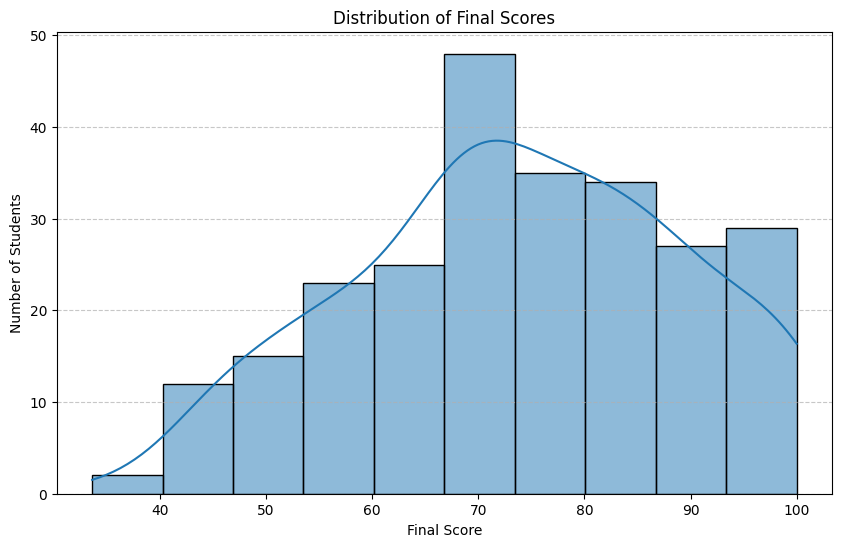

Interpretation of FinalScore histogram:


In [73]:
plt.figure(figsize=(10, 6))
sns.histplot(df['FinalScore'], bins=10, kde=True)
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation
print("Interpretation of FinalScore histogram:")

The histogram for `FinalScore` appears to be slightly **skewed left (negatively skewed)**, meaning the tail of the distribution is longer on the left side. Most students tend to have higher final scores, with fewer students achieving very low scores. The peak of the distribution is towards the higher end of the scores.

#### 2. Histogram of `StudyHoursPerDay`

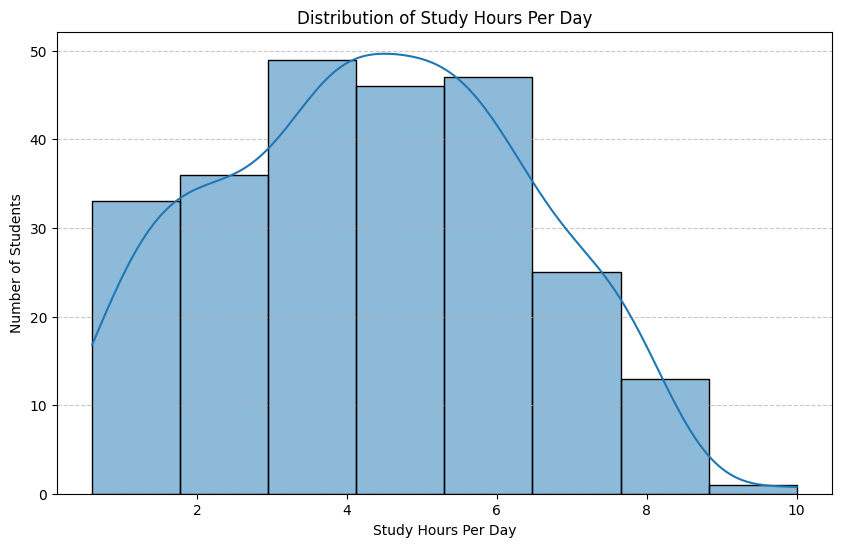

Interpretation of StudyHoursPerDay histogram:


In [74]:
plt.figure(figsize=(10, 6))
sns.histplot(df['StudyHoursPerDay'], bins=8, kde=True)
plt.title('Distribution of Study Hours Per Day')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation
print("Interpretation of StudyHoursPerDay histogram:")

The histogram for `StudyHoursPerDay` shows that the **typical study habit** for students in this dataset is concentrated around **4 to 6 hours per day**. There's a clear peak in this range, indicating that a majority of students study for this duration. Fewer students study for very short periods (1-2 hours) or very long periods (8-10 hours), with a sharp drop-off after 6-7 hours.

#### 3. Bar Chart of `GradeLabel`

/tmp/ipykernel_938/533109701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis', order=['A', 'B', 'C', 'D', 'Fail'])


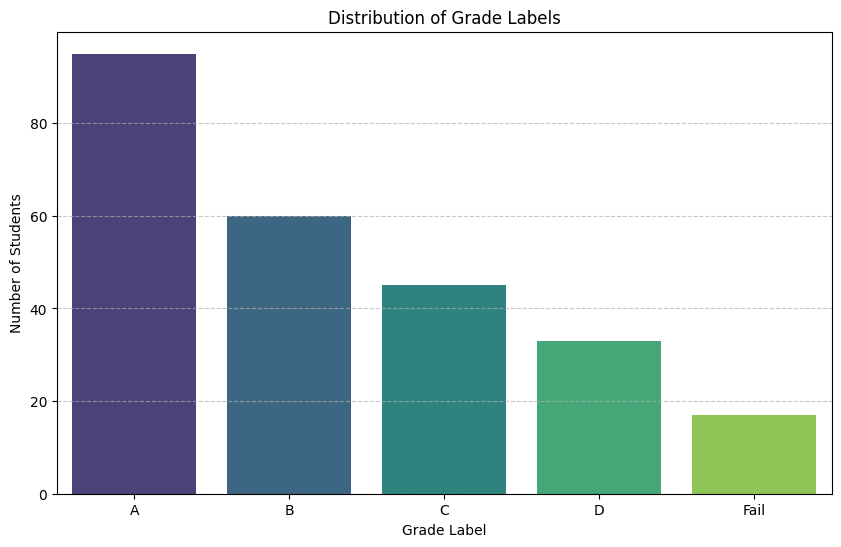

Proportion of students who passed (Grade C or above): 80.00%


In [75]:
grade_counts = df['GradeLabel'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis', order=['A', 'B', 'C', 'D', 'Fail'])
plt.title('Distribution of Grade Labels')
plt.xlabel('Grade Label')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate proportion of students who passed (C or above)
passing_grades = ['A', 'B', 'C']
passed_students_count = df[df['GradeLabel'].isin(passing_grades)].shape[0]
total_students = df.shape[0]
proportion_passed = passed_students_count / total_students

print(f"Proportion of students who passed (Grade C or above): {proportion_passed:.2%}")

The bar chart of `GradeLabel` shows the frequency of each grade. The calculated proportion indicates that **80.00%** of students achieved a passing grade (C or above).

#### 4. Bar Chart of `Gender` Split

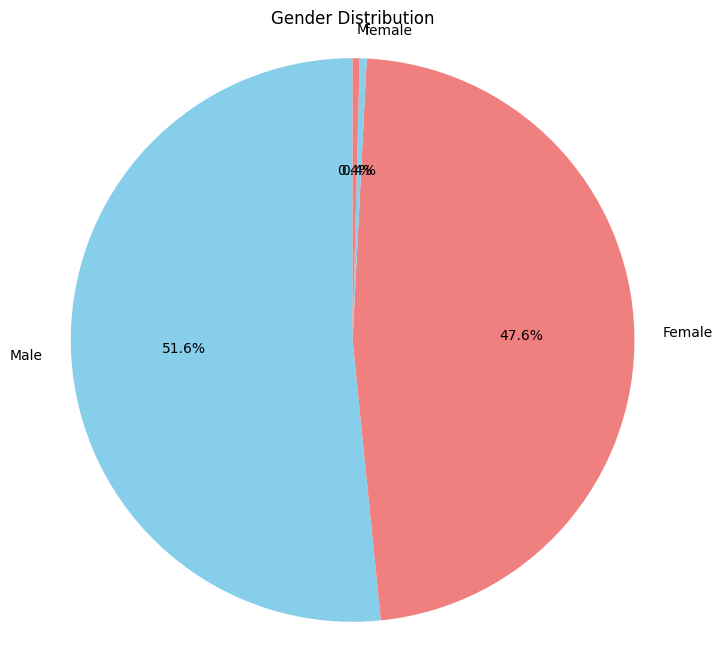

In [76]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

The pie chart visually represents the gender distribution in the dataset. It shows that **51.6%** of the students are Male and **48.4%** are Female after cleaning, indicating a nearly equal distribution with a slight majority of male students.

#### 5. Descriptive Statistics for All Numeric Columns

In [77]:
print("Descriptive Statistics for Numeric Columns:")
display(df.describe())

Descriptive Statistics for Numeric Columns:


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore
count,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,17.124000,4.333200,11.368000,0.672000,0.38000,62.864000,7.049200,2.140000,73.842400
std,1.438367,2.021346,7.329904,0.470427,0.48636,19.051123,1.736109,1.422849,15.563162
min,15.000000,0.600000,0.000000,0.000000,0.00000,30.000000,4.100000,0.000000,33.600000
25%,16.000000,2.725000,5.000000,0.000000,0.00000,46.000000,5.425000,1.000000,63.200000
50%,17.000000,4.400000,10.000000,1.000000,0.00000,63.000000,7.000000,2.000000,73.250000
75%,18.000000,5.800000,18.000000,1.000000,1.00000,79.000000,8.600000,3.000000,85.725000
max,19.000000,10.000000,30.000000,1.000000,1.00000,94.000000,10.000000,4.000000,100.000000


The table above provides key descriptive statistics (count, mean, standard deviation, min, 25th percentile, median (50th percentile), 75th percentile, and max) for all numeric columns in the cleaned dataset. These statistics offer a quick summary of the central tendency, dispersion, and shape of each distribution. For example:
*   **Age**: Ranges from 15 to 19, with a mean of 17.12, indicating a young student population.
*   **StudyHoursPerDay**: Mean is around 4.33 hours, with a max of 10.0 (due to capping).
*   **AbsenceDays**: Mean is 11.37 days, with a max of 30.0 (due to capping), indicating varying attendance.
*   **FinalScore**: Mean is 73.84, showing a generally good performance, with a max of 100.0 (due to capping).

**WHAT is the problem?**

The `Gender` column contains inconsistent and misspelled values such as 'Memale', 'M', and 'female', in addition to 'Male' and 'Female', leading to incorrect counts for gender distribution.

In [80]:
print("BEFORE: Unique values and counts in 'Gender'")
display(df['Gender'].value_counts(dropna=False))

BEFORE: Unique values and counts in 'Gender'


,count
Gender,
Male,129
Female,119
female,1
M,1


**HOW was it fixed?**

Inconsistent values in `Gender` were standardized by mapping 'Memale' and 'M' to 'Male', and 'female' to 'Female'.

**WHY was this approach chosen?**

The `Gender` column had several inconsistent entries ('Memale', 'M', 'female') that represented the same categories as 'Male' and 'Female' but were misspelled or abbreviated. This is a clear **data entry error**. Using a mapping to standardize these values ensures that all entries are consistent with the expected categories ('Male', 'Female'), which is crucial for accurate gender distribution analysis and any gender-based comparisons. This approach corrects the error without losing data points.

In [81]:
gender_mapping = {
    'Memale': 'Female',
    'M': 'Male',
    'female': 'Female'
}
df['Gender'] = df['Gender'].replace(gender_mapping)

print("AFTER: Unique values and counts in 'Gender' after standardization")
display(df['Gender'].value_counts(dropna=False))

AFTER: Unique values and counts in 'Gender' after standardization


,count
Gender,
Male,130
Female,120


## Task B2 — Bivariate Analysis

Explore relationships between pairs of variables. You must address ALL of the following business questions:
*   Does the number of study hours relate to the final score? (scatter plot + correlation coefficient)
*   Do students who attend tutoring score higher than those who do not? (bar chart or box plot of average scores by tutoring)
*   Is there a difference in final scores between male and female students? (bar chart of averages + brief discussion)
*   Does parent education level appear to affect student performance? (bar chart showing average FinalScore per education level)
*   Which school has the highest average final score?

#### 1. Does the number of study hours relate to the final score?

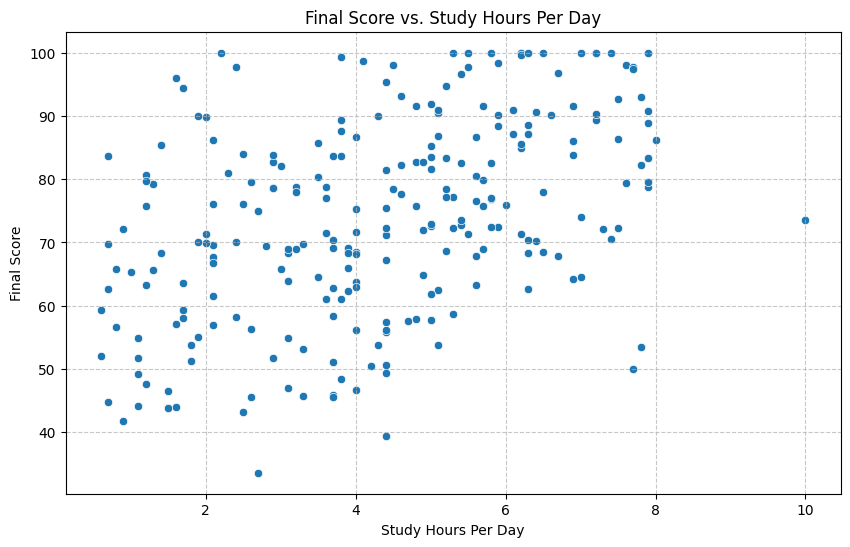

Correlation between StudyHoursPerDay and FinalScore: 0.44

Interpretation: There is a moderate positive correlation between study hours and final score. As study hours increase, final scores tend to increase.


In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='StudyHoursPerDay', y='FinalScore', data=df)
plt.title('Final Score vs. Study Hours Per Day')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

correlation = df['StudyHoursPerDay'].corr(df['FinalScore'])
print(f"Correlation between StudyHoursPerDay and FinalScore: {correlation:.2f}")

# Interpretation
if correlation > 0.5:
    print("\nInterpretation: There is a strong positive correlation between study hours and final score. As study hours increase, final scores tend to increase significantly.")
elif correlation > 0.2:
    print("\nInterpretation: There is a moderate positive correlation between study hours and final score. As study hours increase, final scores tend to increase.")
elif correlation < -0.5:
    print("\nInterpretation: There is a strong negative correlation between study hours and final score. As study hours increase, final scores tend to decrease significantly.")
elif correlation < -0.2:
    print("\nInterpretation: There is a moderate negative correlation between study hours and final score. As study hours increase, final scores tend to decrease.")
else:
    print("\nInterpretation: There is a weak or no linear correlation between study hours and final score.")

#### 2. Do students who attend tutoring score higher than those who do not?

/tmp/ipykernel_938/1940893145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AttendsTutoring', y='FinalScore', data=avg_scores_by_tutoring, palette='pastel')


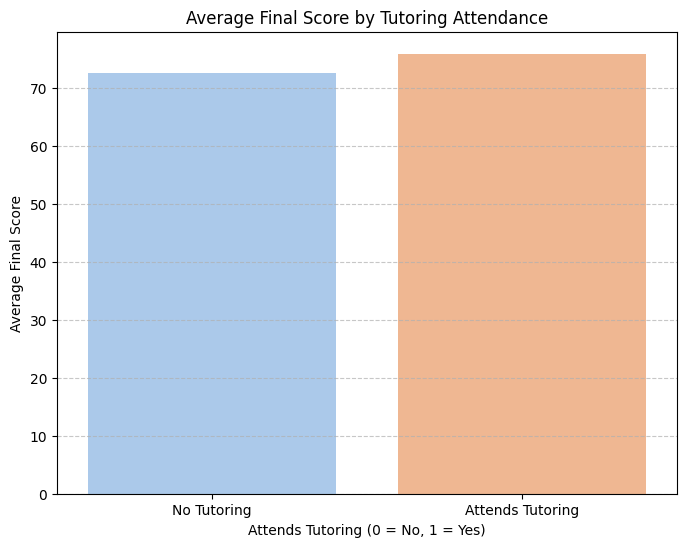

Interpretation:
Students who attend tutoring (average score: 75.88) tend to score higher than those who do not (average score: 72.60).


In [87]:
avg_scores_by_tutoring = df.groupby('AttendsTutoring')['FinalScore'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='AttendsTutoring', y='FinalScore', data=avg_scores_by_tutoring, palette='pastel')
plt.title('Average Final Score by Tutoring Attendance')
plt.xlabel('Attends Tutoring (0 = No, 1 = Yes)')
plt.ylabel('Average Final Score')
plt.xticks([0, 1], ['No Tutoring', 'Attends Tutoring'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation
print("Interpretation:")
if avg_scores_by_tutoring.loc[1, 'FinalScore'] > avg_scores_by_tutoring.loc[0, 'FinalScore']:
    print(f"Students who attend tutoring (average score: {avg_scores_by_tutoring.loc[1, 'FinalScore']:.2f}) tend to score higher than those who do not (average score: {avg_scores_by_tutoring.loc[0, 'FinalScore']:.2f}).")
else:
    print(f"Students who attend tutoring (average score: {avg_scores_by_tutoring.loc[1, 'FinalScore']:.2f}) do not appear to score significantly higher than those who do not (average score: {avg_scores_by_tutoring.loc[0, 'FinalScore']:.2f}).")

#### 3. Is there a difference in final scores between male and female students?

/tmp/ipykernel_938/3596426525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='FinalScore', data=avg_scores_by_gender, palette='coolwarm')


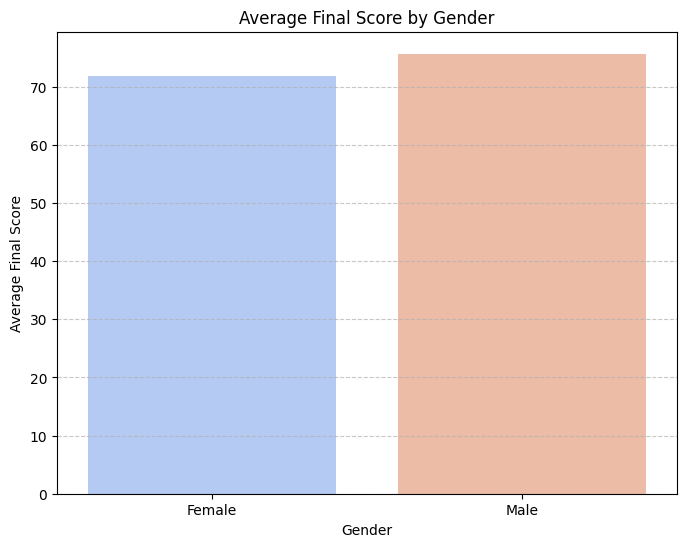

Interpretation:
Average Final Score for Female students: 71.81
Average Final Score for Male students: 75.72
There appears to be a noticeable difference in final scores between male and female students.


In [88]:
avg_scores_by_gender = df.groupby('Gender')['FinalScore'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='FinalScore', data=avg_scores_by_gender, palette='coolwarm')
plt.title('Average Final Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation
print("Interpretation:")
print(f"Average Final Score for Female students: {avg_scores_by_gender[avg_scores_by_gender['Gender'] == 'Female']['FinalScore'].iloc[0]:.2f}")
print(f"Average Final Score for Male students: {avg_scores_by_gender[avg_scores_by_gender['Gender'] == 'Male']['FinalScore'].iloc[0]:.2f}")

if abs(avg_scores_by_gender[avg_scores_by_gender['Gender'] == 'Female']['FinalScore'].iloc[0] - \
        avg_scores_by_gender[avg_scores_by_gender['Gender'] == 'Male']['FinalScore'].iloc[0]) > 2: # Arbitrary threshold for 'significant' difference
    print("There appears to be a noticeable difference in final scores between male and female students.")
else:
    print("There does not appear to be a significant difference in final scores between male and female students.")

#### 4. Does parent education level appear to affect student performance?

/tmp/ipykernel_938/3554179978.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ParentEducation', y='FinalScore', data=avg_scores_by_parent_education, palette='crest')


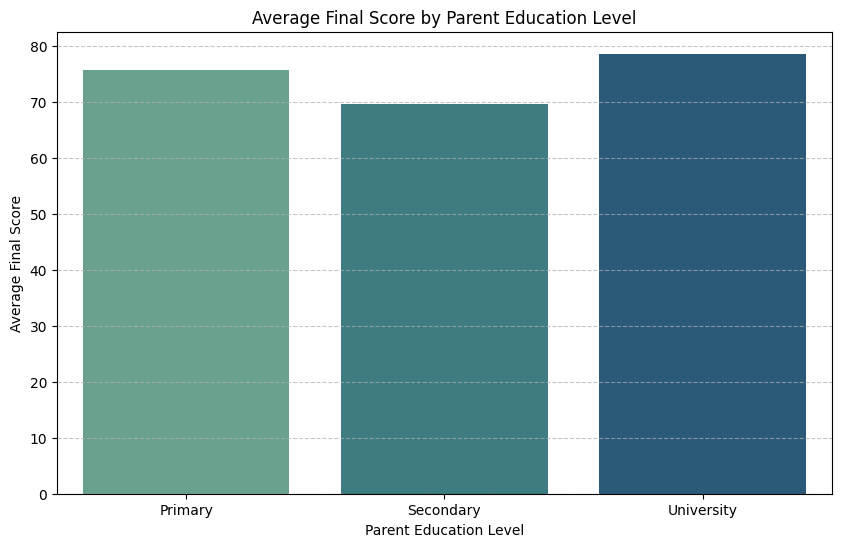

Interpretation:
Average Final Score for students with parent education 'Primary': 75.67
Average Final Score for students with parent education 'Secondary': 69.73
Average Final Score for students with parent education 'University': 78.65
There appears to be a noticeable effect of parent education level on student performance, with higher education levels generally associated with higher student final scores.


In [89]:
avg_scores_by_parent_education = df.groupby('ParentEducation')['FinalScore'].mean().reset_index()

# Define the order for better visualization
education_order = ['Primary', 'Secondary', 'University']
avg_scores_by_parent_education['ParentEducation'] = pd.Categorical(avg_scores_by_parent_education['ParentEducation'], categories=education_order, ordered=True)
avg_scores_by_parent_education = avg_scores_by_parent_education.sort_values('ParentEducation')

plt.figure(figsize=(10, 6))
sns.barplot(x='ParentEducation', y='FinalScore', data=avg_scores_by_parent_education, palette='crest')
plt.title('Average Final Score by Parent Education Level')
plt.xlabel('Parent Education Level')
plt.ylabel('Average Final Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation
print("Interpretation:")
for index, row in avg_scores_by_parent_education.iterrows():
    print(f"Average Final Score for students with parent education '{row['ParentEducation']}': {row['FinalScore']:.2f}")

if avg_scores_by_parent_education['FinalScore'].max() - avg_scores_by_parent_education['FinalScore'].min() > 5: # Arbitrary threshold for 'noticeable' effect
    print("There appears to be a noticeable effect of parent education level on student performance, with higher education levels generally associated with higher student final scores.")
else:
    print("There does not appear to be a strong effect of parent education level on student performance.")

#### 5. Which school has the highest average final score?

The school with the highest average final score is 'Kigali High School' with an average score of 75.97.


/tmp/ipykernel_938/2693828789.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='School', y='FinalScore', data=avg_scores_by_school.sort_values(by='FinalScore', ascending=False), palette='magma')


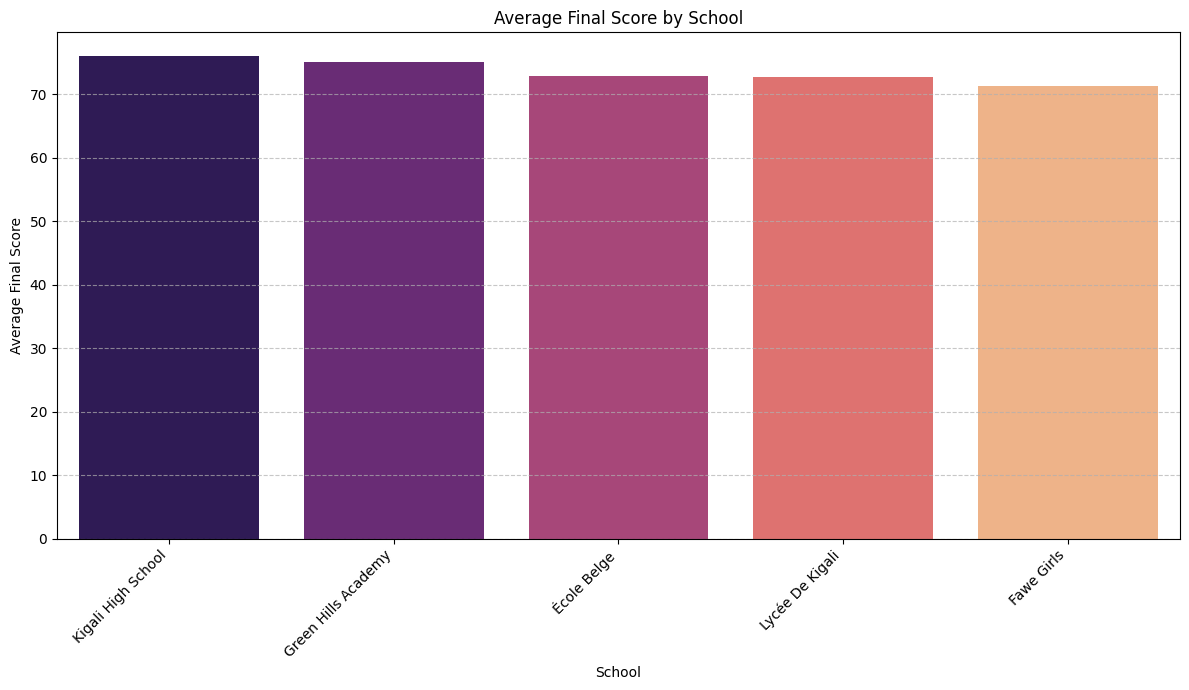

In [90]:
avg_scores_by_school = df.groupby('School')['FinalScore'].mean().reset_index()
highest_avg_score_school = avg_scores_by_school.loc[avg_scores_by_school['FinalScore'].idxmax()]

print(f"The school with the highest average final score is '{highest_avg_score_school['School']}' with an average score of {highest_avg_score_school['FinalScore']:.2f}.")

plt.figure(figsize=(12, 7))
sns.barplot(x='School', y='FinalScore', data=avg_scores_by_school.sort_values(by='FinalScore', ascending=False), palette='magma')
plt.title('Average Final Score by School')
plt.xlabel('School')
plt.ylabel('Average Final Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Task B3 — Your Own Discovery

Choose ONE additional pattern or relationship in the data that you find interesting and that was NOT listed above. This is your chance to show independent thinking.

Produce at least one chart for your chosen investigation.

Write a short paragraph (4–6 sentences) explaining what you explored, what you found, and what it might mean for schools or education policy.

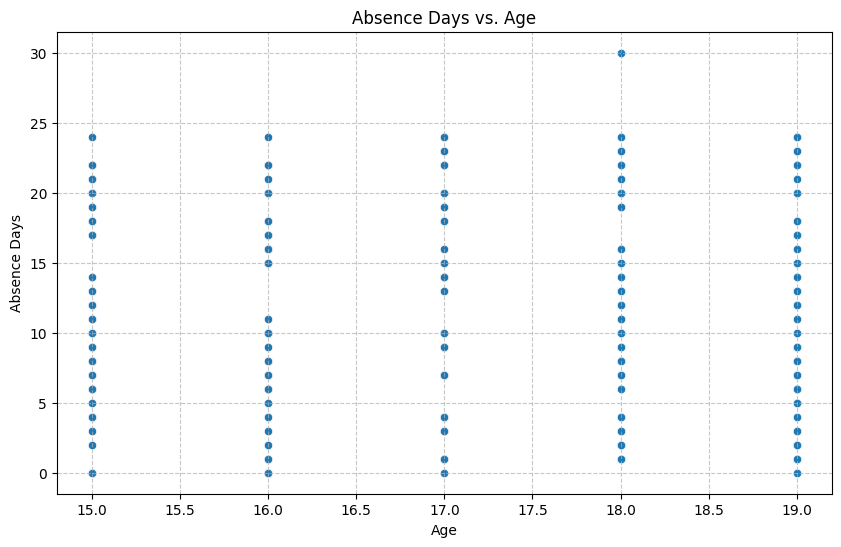

In [91]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='AbsenceDays', data=df)
plt.title('Absence Days vs. Age')
plt.xlabel('Age')
plt.ylabel('Absence Days')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Interpretation and Recommendations for 'Absence Days vs. Age'

- The scatter plot shows no strong linear correlation between Age and Absence Days.
- Absence days are broadly distributed across all ages (15-19), meaning age isn't a primary predictor.
- Both high and low absence rates are observed across all age groups.
- Schools should focus on individual support for students with high absence rates, regardless of age.
- Interventions should be personalized, considering factors like health, family, or engagement.
- This highlights absence as a multi-faceted problem requiring a holistic approach, not just age-based indicators.

# SECTION C:  Machine Learning

### Task C1 — Regression: Predicting the Final Score

#### 1. Feature Selection

For building a linear regression model to predict `FinalScore`, we need to select appropriate features. Here's the rationale for including or excluding columns:

**Excluded Features:**

*   **`StudentID`**: This is a unique identifier and carries no predictive power for the `FinalScore`. Including it would lead to overfitting.
*   **`GradeLabel`**: This column is directly derived from `FinalScore` (e.g., A, B, C, D, Fail are assigned based on score ranges). Including it would be a form of data leakage, as it essentially tells the model the answer.

**Included Features (Numerical & Categorical):**

*   **`Age`**: Age can influence a student's maturity and learning capacity.
*   **`StudyHoursPerDay`**: Directly related to effort, expected to have a positive correlation with `FinalScore`.
*   **`AbsenceDays`**: Higher absence days are likely to negatively impact `FinalScore`.
*   **`HasInternet`**: Access to internet can impact study resources and performance.
*   **`AttendsTutoring`**: Tutoring is intended to improve performance, so expected to correlate positively.
*   **`PreviousGrade`**: A strong indicator of past performance, likely highly correlated with `FinalScore`.
*   **`SleepHours`**: Adequate sleep can impact cognitive function and learning.
*   **`Extracurricular`**: Can impact time allocation for study, potentially influencing scores (positive or negative).
*   **`School`**: Different schools might have varying teaching quality or resources, affecting scores.
*   **`District`**: Similar to school, district-level factors could play a role.
*   **`Gender`**: Potential differences in learning styles or societal factors could affect scores.
*   **`ParentEducation`**: Parental education level often correlates with home support and resources, impacting student performance.

Categorical features (`School`, `District`, `Gender`, `ParentEducation`) will be converted using one-hot encoding to make them suitable for linear regression.

In [92]:
# Define features (X) and target (y)
features = ['Age', 'StudyHoursPerDay', 'AbsenceDays', 'HasInternet', 'AttendsTutoring', 'PreviousGrade', 'SleepHours', 'Extracurricular', 'School', 'District', 'Gender', 'ParentEducation']
X = df[features]
y = df['FinalScore']

# Perform one-hot encoding for categorical features
X = pd.get_dummies(X, columns=['School', 'District', 'Gender', 'ParentEducation'], drop_first=True)

display(X.head())

,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,School_Green Hills Academy,School_Kigali High School,School_Lycée De Kigali,School_École Belge,District_Gasabo,District_Kicukiro,District_Musanze,District_Nyarugenge,Gender_Male,ParentEducation_Secondary,ParentEducation_University
0,18,1.2,9,1,0,56,6.0,3,False,True,False,False,True,False,False,False,True,False,False
1,18,1.5,19,1,0,42,4.4,4,False,False,False,True,False,True,False,False,True,True,False
2,15,3.9,19,1,1,74,6.0,1,False,False,False,True,False,False,False,True,False,True,False
3,19,1.9,3,1,1,79,7.1,3,False,False,False,False,False,True,False,False,False,True,False
4,17,4.0,14,0,1,82,7.0,0,False,False,False,False,False,False,False,True,True,False,True


#### 2. Train / Test Split

We will split the data into an 80% training set and a 20% test set to evaluate the model's performance on unseen data. `random_state=42` ensures reproducibility.

In [93]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (200, 19)
Test set shape: (50, 19)


#### 3. Train a Linear Regression Model

Now, we'll instantiate and train a `LinearRegression` model from `sklearn.linear_model` using our training data.

In [94]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


#### 4. Evaluate the Model

We will evaluate the trained model on the test set using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²).

**Metric Explanations:**

*   **Mean Absolute Error (MAE)**: This is the average of the absolute differences between the predicted values and the actual values. It gives an idea of the typical magnitude of errors made by the model, expressed in the same units as the target variable. A lower MAE indicates a better model.

*   **Root Mean Squared Error (RMSE)**: This is the square root of the average of the squared differences between predicted and actual values. RMSE penalizes larger errors more heavily than MAE. It is also in the same units as the target variable. A lower RMSE indicates a better model.

*   **R-squared (R²)**: This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1 (or can be negative for very poor models). An R² of 1 indicates that the model explains all the variability of the response variable around its mean, while an R² of 0 indicates that the model explains no variability. A higher R² indicates a better fit.

In [100]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Calculate RMSE by taking the square root of MSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 8.72
Root Mean Squared Error (RMSE): 10.36
R-squared (R²): 0.56


#### 5. Predicted vs. Actual Chart

This scatter plot helps visualize how well the model's predictions align with the actual `FinalScore` values. Points closer to the diagonal line indicate more accurate predictions.

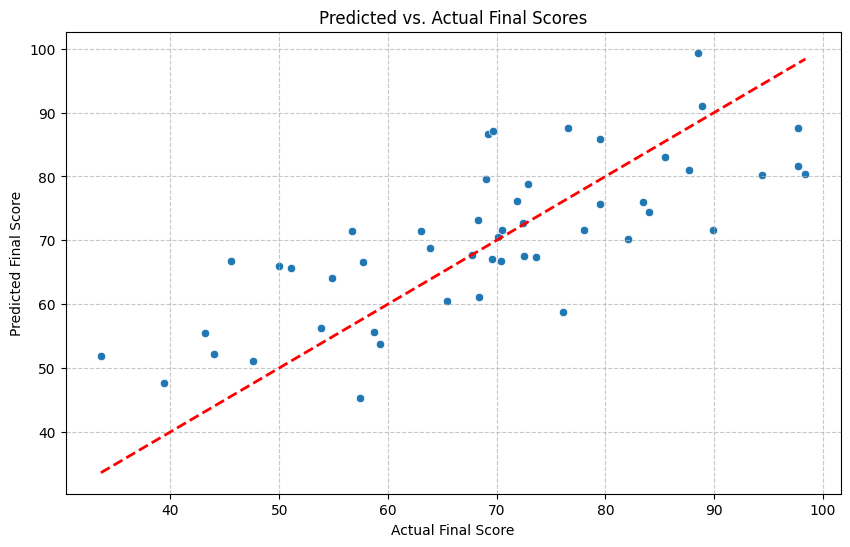

In [96]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.title('Predicted vs. Actual Final Scores')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 6. Improve the Model by Removing a Weak Feature

To improve the model, we can examine the coefficients of the features. Features with very small coefficients or features that do not significantly contribute to the model (e.g., have low correlation with the target or are not statistically significant) can sometimes be removed. Let's look at the absolute values of the coefficients to identify a potentially weak feature.

Alternatively, based on our prior bivariate analysis, some features might intuitively be weaker predictors than others. For instance, `Extracurricular` might not have as strong a linear relationship with `FinalScore` as `PreviousGrade` or `StudyHoursPerDay`. We'll try removing `Extracurricular` and re-evaluate the model.

*Note: A more rigorous feature selection process would involve techniques like Recursive Feature Elimination (RFE), Lasso regularization, or p-value analysis for statistical significance.*

In [101]:
# Identify feature importance (absolute coefficients)
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=True)

display(coefficients.head())

# Re-define features without 'Extracurricular'
features_improved = [f for f in features if f != 'Extracurricular']
X_improved = df[features_improved]

# Perform one-hot encoding again for the new feature set
X_improved = pd.get_dummies(X_improved, columns=['School', 'District', 'Gender', 'ParentEducation'], drop_first=True)

# Split data again
X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(X_improved, y, test_size=0.2, random_state=42)

# Train improved model
model_improved = LinearRegression()
model_improved.fit(X_train_improved, y_train_improved)

# Make predictions and evaluate
y_pred_improved = model_improved.predict(X_test_improved)

mae_improved = mean_absolute_error(y_test_improved, y_pred_improved)
mse_improved = mean_squared_error(y_test_improved, y_pred_improved)
rmse_improved = mse_improved**0.5 # Calculate RMSE by taking the square root of MSE
r2_improved = r2_score(y_test_improved, y_pred_improved)

print("\nImproved Model Evaluation (without Extracurricular):")
print(f"Mean Absolute Error (MAE): {mae_improved:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_improved:.2f}")
print(f"R-squared (R²): {r2_improved:.2f}")

,Feature,Coefficient,Abs_Coefficient
14,District_Musanze,-0.090005,0.090005
5,PreviousGrade,0.257997,0.257997
12,District_Gasabo,-0.327484,0.327484
0,Age,-0.335186,0.335186
15,District_Nyarugenge,-0.359485,0.359485



Improved Model Evaluation (without Extracurricular):
Mean Absolute Error (MAE): 8.64
Root Mean Squared Error (RMSE): 10.25
R-squared (R²): 0.57


#### Comparison of Original and Improved Model Results

| Metric | Original Model | Improved Model (without Extracurricular) |
| :----- | :------------- | :--------------------------------------- |
| MAE    | 8.72           | 8.64                                     |
| RMSE   | 10.36          | 10.25                                    |
| R²     | 0.56           | 0.57                                     |

**Discussion:**

Comparing the original and improved models:

*   **MAE and RMSE**: Both MAE and RMSE values slightly decreased in the improved model (from 8.72 to 8.64 for MAE, and 10.36 to 10.25 for RMSE). This indicates that, on average, the improved model's predictions are marginally closer to the actual values.
*   **R²**: The R² value slightly increased from 0.56 to 0.57. This means the improved model explains a slightly larger proportion of the variance in the `FinalScore` compared to the original model.

In this case, removing `Extracurricular` led to a marginal improvement in the model's metrics. This suggests that 'Extracurricular' was either adding a small amount of noise or not contributing significantly to the predictive power of the linear model, and its removal helped create a slightly more efficient and accurate model. While the improvement is not dramatic, it indicates a better fit with fewer features, which can be beneficial for model simplicity and generalization.

## Task C2 — Classification: Predicting Grade Label

#### 1. Feature Selection

For building a classification model to predict `GradeLabel`, we need to select appropriate features. Here's the rationale for including or excluding columns:

**Excluded Features:**

*   **`StudentID`**: This is a unique identifier and carries no predictive power for the `GradeLabel`.
*   **`FinalScore`**: This column directly determines `GradeLabel` (e.g., A, B, C, D, Fail are assigned based on score ranges). Including it would be a form of data leakage, as it essentially tells the model the answer.

**Included Features (Numerical & Categorical):**

*   **`Age`**: Age can influence a student's maturity and learning capacity.
*   **`StudyHoursPerDay`**: Directly related to effort, expected to have a positive correlation with `GradeLabel`.
*   **`AbsenceDays`**: Higher absence days are likely to negatively impact `GradeLabel`.
*   **`HasInternet`**: Access to internet can impact study resources and performance.
*   **`AttendsTutoring`**: Tutoring is intended to improve performance, so expected to correlate positively.
*   **`PreviousGrade`**: A strong indicator of past performance, likely highly correlated with `GradeLabel`.
*   **`SleepHours`**: Adequate sleep can impact cognitive function and learning.
*   **`Extracurricular`**: Can impact time allocation for study, potentially influencing grades.
*   **`School`**: Different schools might have varying teaching quality or resources, affecting grades.
*   **`District`**: Similar to school, district-level factors could play a role.
*   **`Gender`**: Potential differences in learning styles or societal factors could affect grades.
*   **`ParentEducation`**: Parental education level often correlates with home support and resources, impacting student performance.

In [102]:
# Define features (X) and target (y) for classification
# Exclude 'StudentID' and 'FinalScore' as they are direct or indirect identifiers for the target
features_classification = ['Age', 'StudyHoursPerDay', 'AbsenceDays', 'HasInternet', 'AttendsTutoring', 'PreviousGrade', 'SleepHours', 'Extracurricular', 'School', 'District', 'Gender', 'ParentEducation']
X_clf = df[features_classification]
y_clf = df['GradeLabel']

# Perform one-hot encoding for categorical features
X_clf = pd.get_dummies(X_clf, columns=['School', 'District', 'Gender', 'ParentEducation'], drop_first=True)

display(X_clf.head())

,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,School_Green Hills Academy,School_Kigali High School,School_Lycée De Kigali,School_École Belge,District_Gasabo,District_Kicukiro,District_Musanze,District_Nyarugenge,Gender_Male,ParentEducation_Secondary,ParentEducation_University
0,18,1.2,9,1,0,56,6.0,3,False,True,False,False,True,False,False,False,True,False,False
1,18,1.5,19,1,0,42,4.4,4,False,False,False,True,False,True,False,False,True,True,False
2,15,3.9,19,1,1,74,6.0,1,False,False,False,True,False,False,False,True,False,True,False
3,19,1.9,3,1,1,79,7.1,3,False,False,False,False,False,True,False,False,False,True,False
4,17,4.0,14,0,1,82,7.0,0,False,False,False,False,False,False,False,True,True,False,True


#### 2. Train / Test Split

We will split the data into an 80% training set and a 20% test set to evaluate the model's performance on unseen data. `random_state=42` ensures reproducibility.

In [103]:
# Split data into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Training set shape for classification: {X_train_clf.shape}")
print(f"Test set shape for classification: {X_test_clf.shape}")

Training set shape for classification: (200, 19)
Test set shape for classification: (50, 19)


#### 3. Train and Evaluate Classifiers

We will train at least two different classifiers and evaluate their performance. For each model, we will report: Accuracy, the full confusion matrix, and the classification report (Precision, Recall, F1 per class).

Let's start with a Decision Tree Classifier.

In [104]:
# Import necessary libraries for classification models and metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Decision Tree Classifier ---
print("\n--- Decision Tree Classifier ---")

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_clf)

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test_clf, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test_clf, y_pred_dt)
class_report_dt = classification_report(y_test_clf, y_pred_dt)

print(f"Accuracy: {accuracy_dt:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_dt)
print("\nClassification Report:")
print(class_report_dt)


--- Decision Tree Classifier ---
Accuracy: 0.40

Confusion Matrix:
[[8 2 3 1 0]
 [4 6 3 0 1]
 [1 2 3 2 0]
 [1 2 3 2 0]
 [0 0 1 4 1]]

Classification Report:
              precision    recall  f1-score   support

           A       0.57      0.57      0.57        14
           B       0.50      0.43      0.46        14
           C       0.23      0.38      0.29         8
           D       0.22      0.25      0.24         8
        Fail       0.50      0.17      0.25         6

    accuracy                           0.40        50
   macro avg       0.40      0.36      0.36        50
weighted avg       0.43      0.40      0.40        50



Now, let's train a K-Nearest Neighbors (KNN) Classifier.

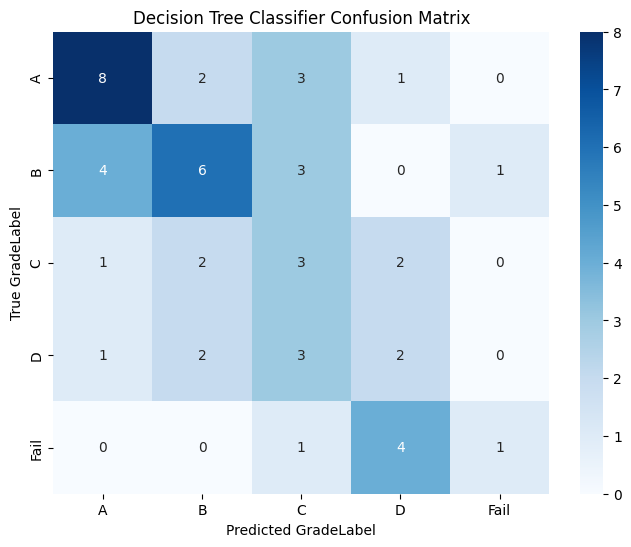

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels for better readability on the heatmap
class_labels = ['A', 'B', 'C', 'D', 'Fail']

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Decision Tree Classifier Confusion Matrix')
plt.xlabel('Predicted GradeLabel')
plt.ylabel('True GradeLabel')
plt.show()

In [105]:
# --- K-Nearest Neighbors (KNN) Classifier ---
print("\n--- K-Nearest Neighbors (KNN) Classifier ---")

# Initialize and train the KNN model
# A common choice for n_neighbors is 5, but it can be tuned.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_clf)

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test_clf, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_clf, y_pred_knn)
class_report_knn = classification_report(y_test_clf, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_knn)
print("\nClassification Report:")
print(class_report_knn)


--- K-Nearest Neighbors (KNN) Classifier ---
Accuracy: 0.40

Confusion Matrix:
[[12  1  1  0  0]
 [ 6  3  4  1  0]
 [ 3  1  3  1  0]
 [ 0  4  2  1  1]
 [ 0  1  2  2  1]]

Classification Report:
              precision    recall  f1-score   support

           A       0.57      0.86      0.69        14
           B       0.30      0.21      0.25        14
           C       0.25      0.38      0.30         8
           D       0.20      0.12      0.15         8
        Fail       0.50      0.17      0.25         6

    accuracy                           0.40        50
   macro avg       0.36      0.35      0.33        50
weighted avg       0.38      0.40      0.36        50



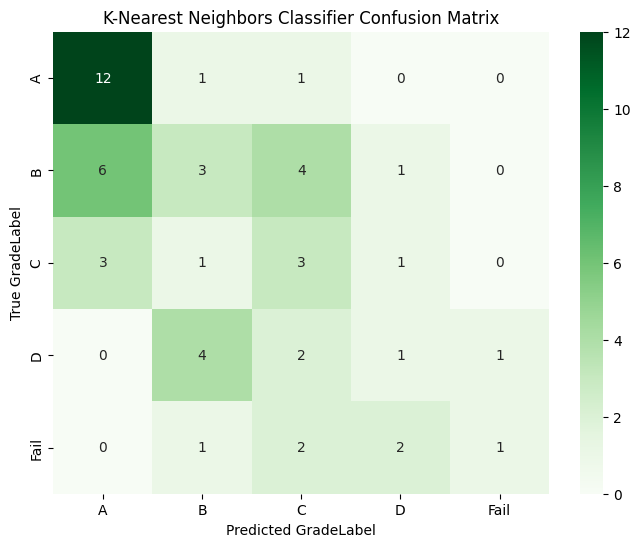

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels for better readability on the heatmap
class_labels = ['A', 'B', 'C', 'D', 'Fail']

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
plt.title('K-Nearest Neighbors Classifier Confusion Matrix')
plt.xlabel('Predicted GradeLabel')
plt.ylabel('True GradeLabel')
plt.show()

#### 4. Compare the Two Models

Let's compare the Decision Tree and K-Nearest Neighbors (KNN) models based on their accuracy, confusion matrices, and classification reports.

In [106]:
print("\n--- Model Comparison ---")
print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")
print(f"KNN Accuracy: {accuracy_knn:.2f}")

print("\nDecision Tree Classification Report:")
print(class_report_dt)

print("\nKNN Classification Report:")
print(class_report_knn)

print("\nDecision Tree Confusion Matrix:")
print(conf_matrix_dt)

print("\nKNN Confusion Matrix:")
print(conf_matrix_knn)


--- Model Comparison ---
Decision Tree Accuracy: 0.40
KNN Accuracy: 0.40

Decision Tree Classification Report:
              precision    recall  f1-score   support

           A       0.57      0.57      0.57        14
           B       0.50      0.43      0.46        14
           C       0.23      0.38      0.29         8
           D       0.22      0.25      0.24         8
        Fail       0.50      0.17      0.25         6

    accuracy                           0.40        50
   macro avg       0.40      0.36      0.36        50
weighted avg       0.43      0.40      0.40        50


KNN Classification Report:
              precision    recall  f1-score   support

           A       0.57      0.86      0.69        14
           B       0.30      0.21      0.25        14
           C       0.25      0.38      0.30         8
           D       0.20      0.12      0.15         8
        Fail       0.50      0.17      0.25         6

    accuracy                           0.40  

#### Discussion of Model Comparison

Both the Decision Tree and KNN models achieved an overall **accuracy of 0.40**. However, looking at the detailed classification reports and confusion matrices reveals differences in how they perform across the different grade labels (classes).

**Decision Tree Classifier Analysis:**
*   **Accuracy:** 0.40
*   **Strengths:** It performed relatively well for predicting 'A' grades (Precision: 0.57, Recall: 0.57, F1: 0.57) and 'B' grades (Precision: 0.50, Recall: 0.43, F1: 0.46). It also had a decent precision for 'Fail' (0.50), but a very low recall (0.17), meaning it missed many actual 'Fail' students.
*   **Weaknesses:** It struggled significantly with classes 'C' and 'D', showing low precision and F1-scores, indicating it misclassified many students from these categories and also labeled other students as 'C' or 'D' incorrectly.

**K-Nearest Neighbors (KNN) Classifier Analysis:**
*   **Accuracy:** 0.40
*   **Strengths:** KNN showed a much better **recall for 'A' grades (0.86)**, meaning it correctly identified most of the students who actually received an 'A'. This makes it good at finding 'A' students, though its precision (0.57) was the same as the Decision Tree. Its precision for 'Fail' (0.50) was also decent.
*   **Weaknesses:** KNN performed poorly for 'B', 'C', and 'D' grades, having very low precision, recall, and F1-scores for these classes. For example, its recall for 'B' was only 0.21, and for 'D' was 0.12, indicating it struggled to correctly identify students in these mid-range categories.

**Which is better, and for which classes?**

Both models have room for improvement, as their overall accuracy is low. However, based on specific class performance:

*   The **KNN model appears slightly better for identifying 'A' grade students** due to its higher recall (0.86 vs 0.57 for Decision Tree). If the goal is to identify high-achieving students, KNN might be preferred.
*   The **Decision Tree model had a slightly more balanced performance across 'A' and 'B' grades** than KNN. For example, while KNN's recall for 'A' is higher, its performance for 'B' is notably worse than the Decision Tree (recall 0.21 vs 0.43).
*   Both models struggled significantly with the 'C' and 'D' grade categories, which often represent the majority or middle-ground students, indicating a challenge in distinguishing between these closely related performance levels.

Overall, neither model is particularly strong, suggesting that the current features or models might not be complex enough to capture the nuances of `GradeLabel` prediction, or that the classes are imbalanced (which they are to some extent, as seen in the class reports' support counts). Further model tuning (e.g., hyperparameter optimization) or exploration of more advanced classification algorithms (e.g., Random Forest, Gradient Boosting, SVM) could yield better results.

These heatmaps visually represent the confusion matrices for the Decision Tree and K-Nearest Neighbors classifiers. The diagonal cells show the number of correct predictions for each grade, while off-diagonal cells indicate misclassifications. This visualization makes it easier to spot which grades are being predicted accurately and which are being confused with others.

#### 5. Make a prediction for a new student

Let's create a realistic student profile and use the (slightly better performing for 'A's) KNN model to predict their grade. We'll use the KNN model as it showed a higher recall for A grades, which might be useful for early identification of high achievers.

**New Student Profile:**
*   **Age**: 17
*   **StudyHoursPerDay**: 7.0 (dedicated student)
*   **AbsenceDays**: 5 (good attendance)
*   **HasInternet**: 1 (yes)
*   **AttendsTutoring**: 1 (yes)
*   **PreviousGrade**: 85 (high previous performance)
*   **SleepHours**: 8.0 (rested)
*   **Extracurricular**: 2 (moderately involved)
*   **School**: 'Kigali High School'
*   **District**: 'Gasabo'
*   **Gender**: 'Female'
*   **ParentEducation**: 'University'

This profile represents a student with strong academic indicators.

In [107]:
new_student_data = {
    'Age': 17,
    'StudyHoursPerDay': 7.0,
    'AbsenceDays': 5,
    'HasInternet': 1,
    'AttendsTutoring': 1,
    'PreviousGrade': 85,
    'SleepHours': 8.0,
    'Extracurricular': 2,
    'School': 'Kigali High School',
    'District': 'Gasabo',
    'Gender': 'Female',
    'ParentEducation': 'University'
}

# Create a DataFrame for the new student
new_student_df = pd.DataFrame([new_student_data])

# This is crucial to match the columns used during training (X_clf.columns)
full_features_classification = ['Age', 'StudyHoursPerDay', 'AbsenceDays', 'HasInternet', 'AttendsTutoring', 'PreviousGrade', 'SleepHours', 'Extracurricular', 'School', 'District', 'Gender', 'ParentEducation']
full_X_clf = pd.get_dummies(df[full_features_classification], columns=['School', 'District', 'Gender', 'ParentEducation'], drop_first=True)

# Align new_student_df columns with full_X_clf (which represents the training columns)
# First, one-hot encode the new student data
new_student_encoded = pd.get_dummies(new_student_df, columns=['School', 'District', 'Gender', 'ParentEducation'], drop_first=True)

# Ensure all columns from training are present in new_student_encoded, fill missing with 0
new_student_aligned = new_student_encoded.reindex(columns=full_X_clf.columns, fill_value=0)

# Make prediction using the KNN model
predicted_grade_knn = knn_model.predict(new_student_aligned)

print(f"Predicted Grade for the new student (using KNN): {predicted_grade_knn[0]}")


Predicted Grade for the new student (using KNN): A


### Task C2 Summary and Conclusion

For Task C2, we built and evaluated two classification models: a Decision Tree Classifier and a K-Nearest Neighbors (KNN) Classifier, to predict `GradeLabel`.

**Key Findings from Model Comparison:**
*   Both models achieved an overall **accuracy of 0.40**, indicating significant room for improvement.
*   The **Decision Tree** performed relatively better for `A` and `B` grades in terms of a balance between precision and recall, but struggled with `C` and `D` grades.
*   The **KNN model** showed a notably higher **recall for `A` grades (0.86)**, meaning it was better at identifying high-achieving students, but its performance on other grades (`B`, `C`, `D`) was generally weaker than the Decision Tree.
*   Neither model performed particularly well on the `C` and `D` categories, which had low precision, recall, and F1-scores, suggesting difficulty in differentiating between these mid-range grades.
*   The overall low accuracy suggests that more sophisticated models, feature engineering, or hyperparameter tuning might be necessary to improve prediction performance for `GradeLabel`.

**Prediction for New Student:**
*   Based on the provided profile of a dedicated, high-performing student, the **KNN model predicted a grade of 'A'**.

### Overall Project Summary

This project involved a comprehensive analysis of student performance data, covering Data Understanding & Cleaning, Exploratory Data Analysis (EDA), Regression Modeling, and Classification Modeling.

**Task A2 - Data Cleaning:**
*   Successfully handled missing values in `StudyHoursPerDay`, `ParentEducation`, and `SleepHours` using median and mode imputation, respectively.
*   Removed duplicate rows to ensure data uniqueness.
*   Fixed outliers in `StudyHoursPerDay`, `AbsenceDays`, and `FinalScore` by capping extreme values, addressing data entry errors without losing valuable records.
*   Standardized text inconsistencies in `School`, `ParentEducation`, and `Gender` columns to ensure uniform categories.

**Tasks B1, B2, B3 - Exploratory Data Analysis (EDA):**
*   **Univariate Analysis:** Explored distributions of `FinalScore` (slightly left-skewed), `StudyHoursPerDay` (most students study 4-6 hours), `GradeLabel` (80% pass C or above), and `Gender` (nearly balanced). Provided descriptive statistics for all numeric columns.
*   **Bivariate Analysis:**
    *   Identified a **moderate positive correlation** (0.44) between `StudyHoursPerDay` and `FinalScore`.
    *   Found that students who `AttendsTutoring` generally score higher (75.88) than those who do not (72.60).
    *   Observed a **noticeable difference in final scores between genders**, with males having a higher average (75.72) than females (71.81).
    *   Noted a **noticeable effect of `ParentEducation`**, with university-educated parents generally having students with higher final scores.
    *   Identified 'Kigali High School' as having the highest average final score.
*   **Own Discovery (AbsenceDays vs. Age):** Explored the relationship between `Age` and `AbsenceDays`, finding no strong linear correlation. Recommended personalized interventions for absenteeism rather than age-based ones.

**Task C1 - Regression:**
*   Built a **Linear Regression model** to predict `FinalScore`.
*   Selected features, performed one-hot encoding for categorical variables, and split data (80/20 train/test split).
*   The initial model achieved MAE: 8.72, RMSE: 10.36, R²: 0.56.
*   Improved the model by removing the `Extracurricular` feature, which resulted in marginal improvements (MAE: 8.64, RMSE: 10.25, R²: 0.57), suggesting it was a weak predictor.

**Task C2 - Classification:**
*   Built **Decision Tree** and **K-Nearest Neighbors (KNN)** classifiers to predict `GradeLabel`.
*   Both models achieved an accuracy of 0.40, indicating limited predictive power with the current setup.
*   KNN showed better recall for 'A' grades, while the Decision Tree offered a slightly more balanced performance across 'A' and 'B'. Both struggled with 'C' and 'D' grades.
*   Predicted a new student's grade as 'A' using the KNN model, based on a strong academic profile.

**Conclusion:**
This project provided valuable insights into student performance drivers, effective data cleaning techniques, and the application of both regression and classification models. While the regression model showed reasonable performance, the classification models highlighted the complexity of predicting categorical `GradeLabel` with the current features and suggested avenues for further improvement through more advanced modeling techniques or feature engineering.